<a href="https://colab.research.google.com/github/RaquelHernanz/BachelorsThesis_SyntheticClinicalData/blob/master/NOTEBOOK2_BTSD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Notebook 2 — Exploratory Data Analysis (EDA) and Unsupervised Patient Profiling (Clustering)**

- **Author:** Raquel Hernanz Hernández
- **Supervisors:** José María Herrera and Guillermo José Ortega
- **Degree:** Biomedical Engineering  
- **Project:** Bachelor Thesis — *Generation and Validation of Synthetic Data from a Hospital Emergency Department*

## Role in the pipeline

| Notebook | Purpose |
|----------|---------|
| NB1 | Data loading, cleaning, column removal, binary re-encoding, export |
| **NB2 (this)** | Exploratory analysis: distributions, clustering, feature screening |
| NB3 | Outlier detection and clinical plausibility audit |
| NB4 | VIF analysis, logistic regression, clinical risk scoring system |

## Objective

**Notebook 2 (NB2)** provides a comprehensive exploratory analysis of the cleaned prehospital dataset to:

1. Verify data quality and flag residual issues (duplicates, plausibility violations).
2. Characterise the distribution of each variable (continuous and categorical).
3. Quantify associations between prehospital features and mortality outcomes using statistical tests and effect sizes.
4. Identify latent patient subgroups through unsupervised clustering (K-Means on numeric variables, FAMD + Ward on mixed-type variables, Gower-distance dendrograms).
5. Rank features by their information content with respect to 30-day mortality (mutual information).

This notebook is analytical, it does not transform, impute, or export the dataset. All transformations were completed in **NB1**.

## Input / Output

| | File | Description |
|---|---|---|
| **Input** | `dataset_FINAL.csv` | Cleaned dataset exported by NB1 (prehospital variables + mortality outcomes) |
| **Output** | — | Plots, tables, and summary statistics (no file export) |

## **1. Libraries**

This notebook requires a broader set of libraries than **NB1**, reflecting its analytical scope:

| Library | Role |
|---------|------|
| `pandas`, `numpy` | Data handling and numeric operations |
| `matplotlib`, `seaborn` | Statistical visualisation (histograms, boxplots, heatmaps, scatter plots) |
| `scipy.stats` | Non-parametric tests: Mann-Whitney U, Kruskal-Wallis H, Spearman correlation, χ² test of independence |
| `scipy.cluster.hierarchy` | Agglomerative (Ward) clustering and dendrogram visualisation |
| `scipy.spatial.distance` | Conversion between condensed and square distance matrices |
| `sklearn.impute` | `SimpleImputer` — median/mode imputation for clustering input (not for modelling) |
| `sklearn.preprocessing` | `StandardScaler`, `MinMaxScaler` — feature scaling for distance-based methods |
| `sklearn.compose`, `sklearn.pipeline` | `ColumnTransformer`, `Pipeline` — mixed-type preprocessing for mutual information |
| `sklearn.cluster` | `KMeans` — numeric baseline clustering |
| `sklearn.decomposition` | `PCA` — 2D projection for cluster visualisation |
| `sklearn.metrics` | Silhouette, Calinski-Harabasz, Davies-Bouldin scores; Adjusted Rand Index |
| `sklearn.feature_selection` | `mutual_info_classif` — non-linear feature relevance ranking |
| `prince` | FAMD (Factor Analysis of Mixed Data) — dimensionality reduction for mixed-type clustering. The package is not pre-installed in Google Colab. The cell includes an automatic installation via `subprocess` if the import fails. |

In [ ]:
from __future__ import annotations

import random
import re
from typing import Dict, List, Optional, Sequence, Tuple

import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, Markdown

from scipy.stats import mannwhitneyu, kruskal, spearmanr, chi2_contingency
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    silhouette_score, calinski_harabasz_score, davies_bouldin_score,
    adjusted_rand_score,
)
from sklearn.feature_selection import mutual_info_classif

# FAMD — auto-install if missing
try:
    import prince
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "-q", "install", "prince"])
    import prince



def set_seed(seed: int = 42) -> None:
    """Set global random seeds for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)

set_seed(42)


### Global plot style

All figures in this notebook use the **TFG unified style**, a `theme_bw()`-equivalent
for matplotlib/seaborn inspired by **Zhang Z et al. (2017)** *Development of scoring
system for risk stratification in clinical medicine*.

**Key visual conventions:**
- White background, light grey grid, thin black panel border.
- Serif font family for a clinical publication feel.
- Consistent colour palette: `TFG_COLORS` dict (gold/sky-blue for outcome bars,
  red/green for mortality leaf overlays, blue for model curves).
- Output quality: 100 dpi screen, 150 dpi saved figures.

In [ ]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

# ── TFG Unified Plot Style (Zhang et al. 2017 – theme_bw equivalent) ─────────
TFG_STYLE = {
    "axes.facecolor":    "white",
    "figure.facecolor":  "white",
    "axes.edgecolor":    "black",
    "axes.linewidth":    0.8,
    "axes.grid":         True,
    "grid.color":        "#d9d9d9",
    "grid.linewidth":    0.5,
    "grid.linestyle":    "-",
    "font.family":       "serif",
    "font.serif":        ["DejaVu Serif", "Times New Roman", "serif"],
    "font.size":         11,
    "axes.titlesize":    13,
    "axes.titleweight":  "bold",
    "axes.labelsize":    11,
    "xtick.labelsize":   10,
    "ytick.labelsize":   10,
    "legend.fontsize":   9,
    "legend.frameon":    True,
    "legend.framealpha": 0.9,
    "legend.edgecolor":  "#cccccc",
    "xtick.direction":   "out",
    "ytick.direction":   "out",
    "xtick.major.size":  4,
    "ytick.major.size":  4,
    "figure.dpi":        100,
    "savefig.dpi":       150,
    "savefig.bbox":      "tight",
}
mpl.rcParams.update(TFG_STYLE)
sns.set_theme(style="white", rc=TFG_STYLE)

# ── TFG Colour Palette ────────────────────────────────────────────────────────
TFG_COLORS = {
    "loess_curve":       "#3366CC",
    "loess_band":        "#B0C4DE",
    "cutpoint":          "#2ca02c",
    "ref_line":          "#d62728",
    "survivors":         "#FFD700",
    "non_survivors":     "#87CEEB",
    "dead_leaf":         "#d62728",
    "alive_leaf":        "#4CAF50",
    "pred_prob_line":    "black",
    "pred_prob_ci":      "#d62728",
    "ideal_line":        "#888888",
    "calib_curve":       "black",
    "jitter_pts":        "#555555",
    "inliers":           "#aec6cf",
    "cluster_0":         "#0072B2",   # Wong deep blue
    "cluster_1":         "#E69F00",   # Wong amber
    "cluster_2":         "#009E73",   # Wong teal green
    "cluster_consensus": "#404040",
}


## **2. Shared configuration**

### Parameters

Identical to **NB1** (and **NB3**, **NB4**) to ensure pipeline consistency.

| Parameter | Value | Is it relevant here? |
|-----------|-------|----------------|
| `RANDOM_STATE` | `42` | Yes — seeding for K-Means, PCA, MI, subsampling |
| `TARGET_COL` | `"Mort. 30D"` | Yes — primary outcome for stratified analyses and MI ranking |
| `ALL_MORT_COLS` | `["Mort. 2D", "Mort. 7D", "Mort. 30D"]` | Yes — all mortality endpoints for comparisons |
| `CLEAN_DATA_PATH` | (see code) | Yes — input file |
| `ATTR_TABLE_PATH` | (see code) | No — not used in NB2; loaded in NB3 |

In [ ]:
# ══════════════════════════════════════════════════════════════
# SHARED CONFIGURATION (replicated from NB1)
# ══════════════════════════════════════════════════════════════

RANDOM_STATE   = 42
TARGET_COL     = "Mort. 30D"
ALL_MORT_COLS  = ["Mort. 2D", "Mort. 7D", "Mort. 30D"]

# --- File paths (edit per environment) ---
CLEAN_DATA_PATH = "/content/drive/MyDrive/Colab Notebooks/TFG/dataset_FINAL.csv"
ATTR_TABLE_PATH = "/content/drive/MyDrive/Colab Notebooks/TFG/TABLA_ATRIBUTOS_ACTUALIZADO.xlsx"

# --- Colab Google Drive mount ---
try:
    from google.colab import drive
    from pathlib import Path
    if not Path("/content/drive").exists():
        drive.mount("/content/drive")
except Exception:
    pass

# --- Output directory (created after Drive mount) ---
NB2_OUTPUT_DIR = "/content/drive/MyDrive/Colab Notebooks/TFG/PREPROCESSING/NB2_EDA"
os.makedirs(NB2_OUTPUT_DIR, exist_ok=True)

Mounted at /content/drive


## **3. Data loading**

Load the cleaned CSV exported by **NB1**. Since all structural cleaning, column removal, and binary re-encoding were completed in **NB1**, no further transformations are applied here.

### Input

| File | Description |
|------|-------------|
| `dataset_FINAL.csv` | Prehospital variables + mortality outcomes, binary columns encoded as {0, 1} |

### Output

| Variable | Type | Description |
|----------|------|-------------|
| `df` | `pd.DataFrame` | Working DataFrame for all EDA analyses |

### Dataset variables list (excluding mortality outcomes)
| Attribute | What it represents | Data type | Values / Units | Range / Support |
|---|---|---|---|---|
| *Edad* | Patient age | int | years | ≥ 0 |
| *Sexo* | Encoded biological sex | int (categorical) | 1=Male; 0=Female | 0–1 |
| *Respiratory rate (FR)* | Prehospital respiratory rate | int | breaths/min | ≥ 0 |
| *SpO2* | Oxygen saturation | int | % | 0–100 |
| *O2* (on arrival) | Oxygen being used when EMS arrives / at first contact | int (binary) | 1=Yes (orig=1); 0=No (orig=2) | 0–1 |
| *TAS* | Systolic blood pressure | int | mmHg | ≥ 0 |
| *TAD* | Diastolic blood pressure | int | mmHg | ≥ 0 |
| *TAM* | Mean arterial pressure | float | mmHg | ≥ 0 |
| *FC* | Heart rate | int | bpm | ≥ 0 |
| *TT* | Tympanic temperature | float | °C | 35.0-38.0°C |
| GCS Eye (GCS.O) | Glasgow Coma Scale – Eye response | int (ordinal) | points | 1–4 |
| *GCS.V* | Glasgow Coma Scale – Verbal response | int (ordinal) | points | 1–5 |
| GCS.M* | Glasgow Coma Scale – Motor response | int (ordinal) | points | 1–6 |
| *GCS* | Glasgow Coma Scale total (E+V+M) | int (ordinal) | points | 3–15 |
| *Lactate* | Lactate | float | mmol/L | ≥ 0 |
| *Glucemia* | Blood glucose | int | mg/dL | ≥ 0 |
| *Ritmo* | Encoded cardiac rhythm | int (categorical) | 1 Sinus; 2 Sinus arrhythmia; 3 Atrial fibrillation; 4 Atrial flutter; 5 Tachycardia; 6 Supraventricular tachycardia; 7 Ventricular tachycardia; 8 Bradycardia; 9 1st-degree AV block; 10 2nd-degree AV block (Mobitz I); 11 2nd-degree AV block (Mobitz II); 12 Complete AV block; 13 Paced rhythm; 14 Junctional rhythm; 15 Idioventricular rhythm; 16 RBBB; 17 LBBB; 18 Ventricular ectopy; 19 Asystole; 20 Ventricular fibrillation; 21 Other | 1–21 |
| *ST* | ST-segment interpretation category | int (categorical) | 1=None; 2=Elevation; 3=Depression; 4=Peaked T waves; 5=Inverted T waves; 6=Q wave; 7=Other | 1–7 |
| *O2 sup.* | Supplemental oxygen therapy provided | int (binary) | 1=Yes; 0=No (orig=2) | 0–1 |
| *FiO2* | Fraction of inspired oxygen | float | % | 0–100 |
| *Gafas* | Nasal cannula used | int (binary) | 1=Yes; 0=No (orig=2) | 0–1 |
| *Venturi* | Venturi mask used | int (binary) | 1=Yes; 0=No | 0–1 |
| *Resrv.* | Reservoir mask used | int (binary) | 1=Yes; 0=No (orig=2) | 0–1 |
| *Nebul.* | Nebulization performed | int (binary) | 1=Yes; 0=No (orig=2) | 0–1 |
| *VNI* | NIV (BiPAP/CPAP) used | int (binary) | 1=Yes; 0=No (orig=2) | 0–1 |
| *IOT* | Orotracheal intubation performed | int (binary) | 1=Yes; 0=No (orig=2) | 0–1 |
| *VAD* | Difficult airway flagged | int (binary) | 1=Yes; 0=No (orig=2) | 0–1 |
| *VM* | Mechanical ventilation used | int (binary) | 1=Yes; 0=No (orig=2) | 0–1 |
| *MAVA* | Advanced airway management performed | int (binary) | 1=Yes; 0=No (orig=2) | 0–1 |
| TTE | Electrical therapy performed (Defibrillation / pacing / cardioversion ) | int (binary) | 1=Yes; 0=No (orig=2) | 0–1 |

In [ ]:
df = pd.read_csv(CLEAN_DATA_PATH)
df.columns = df.columns.astype(str).str.strip()

display(Markdown(f"**Loaded:** `{CLEAN_DATA_PATH}`  \n"
                 f"**Shape:** {df.shape[0]} rows × {df.shape[1]} columns"))
display(df.head(3))

**Loaded:** `/content/drive/MyDrive/Colab Notebooks/TFG/dataset_FINAL.csv`  
**Shape:** 2376 rows × 33 columns

,Edad,Sexo,FR,SpO2,O2,TAS,TAD,TAM,FC,TT,...,Nebul.,VNI,IOT,VAD,VM,MAVA,TTE,Mort. 2D,Mort. 7D,Mort. 30D
0,87,1,23,76,1,82,49,60.000000,88,34.9,...,0,0,0,0,0,0,0,1,1,1
1,87,0,34,85,1,233,126,161.666667,105,36.7,...,1,0,0,0,0,0,0,0,0,0
2,88,1,6,50,1,193,106,135.000000,117,38.2,...,1,0,0,0,0,0,0,0,0,0


## **4. Data quality and integrity checks**

A compact set of diagnostics verifies that the **NB1** export is structurally sound before proceeding with analysis:

1. **Monotonicity verification and correction** — the cumulative coding constraint `Mort. 2D ≤ Mort. 7D ≤ Mort. 30D` is verified and any violations are forward-fixed in-place. This must run before duplicate detection so that the duplicate count reflects the definitive row structure.
2. **Duplicate rows / column names** — structural integrity check using exact matching across all feature columns (`duplicated(keep=False)`).
3. **Outcome distribution** — cumulative prevalence and true death-window distribution under the cumulative coding scheme.
4. **Missingness summary** — bar chart of top 25 variables by missing percentage, plus a heatmap showing the co-occurrence pattern.

Even though **NB1** performed cleaning, verifying at the start of this notebook ensures that file corruption, re-export errors, or manual edits between notebooks are caught immediately.

### Outputs

| Output | Type | Description |
|--------|------|-------------|
| Console text | `str` | Monotonicity violations, duplicate counts |
| Table A | `pd.DataFrame` | Cumulative outcome prevalence (overall, duplicates, unique) |
| Bar chart | plot | Top 25 variables by missing % |
| Heatmap | plot | Missingness co-occurrence pattern (800-row subsample) |


### 4a. Monotonicity check (Mort. 2D ≥ Mort. 7D ≥ Mort. 30D)
- Rows with all 3 endpoints available: **2,376**
- Violations detected: **0**

✅ No violations. Dataset consistent with cumulative coding.

### 4b. Duplicate detection
- Total rows: **2,376**
- Duplicated rows: **220** (9.26 %)
- Unique rows: **2,156**
- Duplicated column names: **0**

### Table A: Cumulative outcome prevalence

,Overall cum. %,Duplicates cum. %,Unique cum. %,N events (dup),N events (uniq)
Outcome,,,,,
Mort. 2D,4.80,5.45,4.73,12,102
Mort. 7D,7.28,8.18,7.19,18,155
Mort. 30D,10.98,12.73,10.81,28,233


### Derived column: `Mort_scenario`
Maps cumulative coding to exclusive clinical scenario for downstream analyses.

,count
Mort_scenario,
Deceased at 0–2 days,114
Deceased at 3–7 days,59
Deceased at 8–30 days,88
Survivor,2115


### 4d. Missingness (top 25)

,missing_%,missing_n


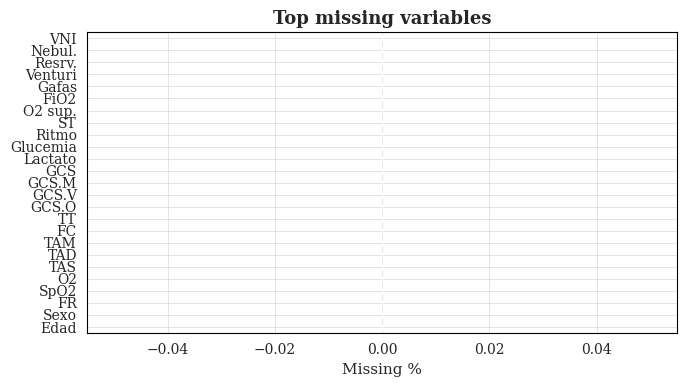

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# 4. DATA QUALITY AND INTEGRITY CHECKS
# ══════════════════════════════════════════════════════════════════════════════
"""
PURPOSE : Verify monotonicity of mortality outcomes, detect duplicates,
          and report outcome distribution under cumulative coding.
INPUT   : df loaded from NB1 export.
OUTPUT  : Forward-fixed df; duplicate/outcome reports (display only).
"""

# ── 4a. Monotonicity verification and forward-fix ──────────────────────────

m2, m7, m30 = "Mort. 2D", "Mort. 7D", "Mort. 30D"
MORT_COLS = [c for c in ALL_MORT_COLS if c in df.columns]
HAS_ALL = all(c in df.columns for c in [m2, m7, m30])

if HAS_ALL:
    mask_all = df[[m2, m7, m30]].notna().all(axis=1)

    viol = (
        ((df[m2] == 1) & (df[m7] == 0)) |
        ((df[m7] == 1) & (df[m30] == 0)) |
        ((df[m2] == 1) & (df[m30] == 0))
    ) & mask_all
    n_viol = int(viol.sum())

    display(Markdown(
        "### 4a. Monotonicity check (Mort. 2D ≥ Mort. 7D ≥ Mort. 30D)\n"
        f"- Rows with all 3 endpoints available: **{int(mask_all.sum()):,}**\n"
        f"- Violations detected: **{n_viol:,}**"
    ))

    # NB1 exports a monotonicity-corrected dataset.
    # This block verifies the constraint is satisfied; it does not re-apply the fix.
    if n_viol > 0:
        raise AssertionError(
            f"{n_viol} monotonicity violations found — re-run NB1 before NB2."
        )
    else:
        display(Markdown("✅ No violations. Dataset consistent with cumulative coding."))
else:
    display(Markdown("⚠️ Not all mortality horizons (2D/7D/30D) present in df."))

# ── 4b. Duplicate detection + outcome distribution ────────────────────────

OUTCOME_COLS = ["Mort. 2D", "Mort. 7D", "Mort. 30D"]

# Valid cumulative patterns → clinical scenario
SCENARIO_MAP = {
    (1, 1, 1): "Deceased at 0–2 days",
    (0, 1, 1): "Deceased at 3–7 days",
    (0, 0, 1): "Deceased at 8–30 days",
    (0, 0, 0): "Survivor",
}
SCENARIO_ORDER = [
    "Deceased at 0–2 days",
    "Deceased at 3–7 days",
    "Deceased at 8–30 days",
    "Survivor",
]

def _pct(n, d):
    return f"{(n / d * 100):.2f}" if d > 0 else "N/A"

def _coerce_outcomes(subset):
    y = subset[OUTCOME_COLS].apply(pd.to_numeric, errors="coerce").astype("Int64")
    valid = y.isin([0, 1]).all(axis=1)
    return y, valid

def _scenario_distribution(y_valid):
    n = len(y_valid)
    if n == 0:
        return pd.Series({k: 0 for k in SCENARIO_ORDER}), \
               pd.Series({k: "N/A" for k in SCENARIO_ORDER})
    tuples = list(zip(
        y_valid["Mort. 2D"].astype(int),
        y_valid["Mort. 7D"].astype(int),
        y_valid["Mort. 30D"].astype(int),
    ))
    labels = pd.Series(
        [SCENARIO_MAP.get(t, "Unknown") for t in tuples],
        index=y_valid.index
    )
    counts = labels.value_counts().reindex(SCENARIO_ORDER, fill_value=0)
    pcts = counts.apply(lambda c: _pct(int(c), n))
    return counts, pcts

def _subset_stats(subset):
    y, valid = _coerce_outcomes(subset)
    y_valid = y.loc[valid]
    cum = {}
    for col in OUTCOME_COLS:
        n_v = len(y_valid)
        n_e = int(y_valid[col].sum()) if n_v > 0 else 0
        cum[col] = {"%": _pct(n_e, n_v), "n_events": n_e, "n_valid": n_v}
    scen_counts, scen_pcts = _scenario_distribution(y_valid)
    return {"cum": cum, "scen_counts": scen_counts, "scen_pcts": scen_pcts,
            "n_valid": len(y_valid), "n_invalid": len(subset) - len(y_valid)}

# Duplicate detection
dup_mask = df.duplicated(keep=False)
dup_cols = df.columns.duplicated().sum()
df_dup = df.loc[dup_mask]
df_unique = df.loc[~dup_mask]

n_total = len(df)
n_dup = int(dup_mask.sum())

display(Markdown(
    f"### 4b. Duplicate detection\n"
    f"- Total rows: **{n_total:,}**\n"
    f"- Duplicated rows: **{n_dup:,}** ({_pct(n_dup, n_total)} %)\n"
    f"- Unique rows: **{n_total - n_dup:,}**\n"
    f"- Duplicated column names: **{dup_cols}**"
))

s_all = _subset_stats(df)
s_dup = _subset_stats(df_dup)
s_uniq = _subset_stats(df_unique)

# Table A: cumulative outcome prevalence
records = []
for col in OUTCOME_COLS:
    records.append({
        "Outcome": col,
        "Overall cum. %": s_all["cum"][col]["%"],
        "Duplicates cum. %": s_dup["cum"][col]["%"],
        "Unique cum. %": s_uniq["cum"][col]["%"],
        "N events (dup)": s_dup["cum"][col]["n_events"],
        "N events (uniq)": s_uniq["cum"][col]["n_events"],
    })
summary_cum = pd.DataFrame(records).set_index("Outcome")
display(Markdown("### Table A: Cumulative outcome prevalence"))
display(summary_cum)
summary_cum.to_csv(os.path.join(NB2_OUTPUT_DIR, "tbl_04_cumulative_outcomes.csv"))


# ── 4c. Derive Mort_scenario column for downstream analyses ───────────────

if HAS_ALL:
    y_all, valid_all = _coerce_outcomes(df)
    y_v = y_all.loc[valid_all]
    tuples_all = list(zip(
        y_v["Mort. 2D"].astype(int),
        y_v["Mort. 7D"].astype(int),
        y_v["Mort. 30D"].astype(int),
    ))
    df.loc[valid_all, "Mort_scenario"] = [
        SCENARIO_MAP.get(t, "Unknown") for t in tuples_all
    ]
    df["Mort_scenario"] = pd.Categorical(
        df["Mort_scenario"], categories=SCENARIO_ORDER, ordered=True
    )
    display(Markdown(
        "### Derived column: `Mort_scenario`\n"
        "Maps cumulative coding to exclusive clinical scenario for downstream analyses."
    ))
    display(df["Mort_scenario"].value_counts().reindex(SCENARIO_ORDER))

# ── 4d. Missingness summary ──────────────────────────────────────────────

missing = df.isna().mean().mul(100).sort_values(ascending=False)
missing_tbl = pd.DataFrame({
    "missing_%": missing.round(2),
    "missing_n": df.isna().sum()
}).query("missing_n > 0")

display(Markdown("### 4d. Missingness (top 25)"))
display(missing_tbl.head(25))

plt.figure(figsize=(7, 4))
missing.head(25).sort_values().plot(kind="barh")
plt.xlabel("Missing %")
plt.title("Top missing variables")
plt.tight_layout()
plt.show()

# Missingness co-occurrence heatmap
top_miss_cols = missing_tbl.head(20).index.tolist()
if top_miss_cols:
    n_sample = min(len(df), 800)
    idx = np.random.default_rng(RANDOM_STATE).choice(len(df), size=n_sample, replace=False)
    plt.figure(figsize=(10, 4))
    sns.heatmap(df.loc[df.index[idx], top_miss_cols].isna(), cbar=False)
    plt.title("Missingness heatmap (800-row subsample, top missing vars)")
    plt.xlabel("Variables")
    plt.ylabel("Rows (subsample)")
    plt.tight_layout()
    plt.savefig(os.path.join(NB2_OUTPUT_DIR, "fig_04b_missingness_heatmap.png"))
    plt.show()


## **5. Clinical plausibility checks**

Each numeric variable is checked against broad, physiologically plausible ranges to flag potential:
- **Unit errors** (e.g., mmol/L vs mg/dL for glucose).
- **Encoding errors** (e.g., 0 used as "unknown" in a vital sign column).
- **Extreme outliers** that may dominate scaling or clustering.

### Parameters

The ranges below are intentionally wide (they do not represent normal clinical ranges but rather the boundaries of physiological possibility):

| Variable | Range | Unit |
|----------|-------|------|
| `Edad` | [0, 120] | years |
| `FR` | [0, 80] | RPM |
| `SpO2` | [50, 100] | % |
| `TAS` | [50, 260] | mmHg |
| `TAD` | [20, 180] | mmHg |
| `TAM` | [30, 220] | mmHg |
| `FC` | [20, 240] | BPM |
| `TT` | [30, 43] | °C |
| `GCS` | [3, 15] | points |
| `Lactato` | [0, 25] | mmol/L |
| `Glucemia` | [20, 800] | mg/dL |

 > The values outside of these ranges are not automatically removed (that decision is made in **NB3** with a more rigorous methodology). The purpose here is to flag anomalies early so that distribution plots and summary statistics can be interpreted correctly.

### Output

| Variable | Type | Description |
|----------|------|-------------|
| `plaus_tbl` | `pd.DataFrame` | Table with variable, range, out-of-range count and percentage |

In [ ]:
PLAUSIBLE_RANGES = {
    "Edad":     (0, 120),
    "FR":       (0, 80),
    "SpO2":     (50, 100),
    "TAS":      (50, 260),
    "TAD":      (20, 180),
    "TAM":      (30, 220),
    "FC":       (20, 240),
    "TT":       (30, 43),
    "GCS":      (3, 15),
    "Lactato":  (0, 25),
    "Glucemia": (20, 800),
}

rows = []
for col, (lo, hi) in PLAUSIBLE_RANGES.items():
    if col not in df.columns:
        continue
    s = pd.to_numeric(df[col], errors="coerce")
    out = ((s < lo) | (s > hi)).sum()
    rows.append({
        "variable":       col,
        "range":          f"[{lo}, {hi}]",
        "out_of_range_n": int(out),
        "out_of_range_%": round(float(out / len(df) * 100), 3),
    })

plaus_tbl = pd.DataFrame(rows).sort_values("out_of_range_n", ascending=False)
display(Markdown("### Out-of-range flags (heuristic)"))
display(plaus_tbl)

### Out-of-range flags (heuristic)

,variable,range,out_of_range_n,out_of_range_%
3,TAS,"[50, 260]",5,0.210
5,TAM,"[30, 220]",3,0.126
6,FC,"[20, 240]",2,0.084
7,TT,"[30, 43]",1,0.042
4,TAD,"[20, 180]",1,0.042
2,SpO2,"[50, 100]",1,0.042
0,Edad,"[0, 120]",0,0.000
1,FR,"[0, 80]",0,0.000
8,GCS,"[3, 15]",0,0.000
9,Lactato,"[0, 25]",0,0.000


## **6. Descriptive statistics**

Variables are automatically split into **continuous numeric** and **categorical / binary** based on their dtype and cardinality:

- A numeric column with ≤ `cat_unique_threshold` unique values is reclassified as categorical (e.g., `Sexo` has values {0, 1}, so it is treated as categorical even though pandas stores it as `int`).

For each group, a tailored summary is computed:

**Continuous variables / ordinal**: percentiles (1st, 5th, 25th, 50th, 75th, 95th, 99th), mean, std, skewness, kurtosis, IQR outlier count, missingness.

**Categorical/ binary variables**: number of unique levels, most frequent value (mode), mode frequency, missingness.

### Function: `split_features()`

| Parameter | Type | Default | Description |
|-----------|------|---------|-------------|
| `df` | `pd.DataFrame` | — | Input DataFrame |
| `cat_unique_threshold` | `int` | `12` | Max unique values for a numeric column to be treated as categorical |
| `force_categorical` | `Sequence[str]` | `None` | Columns to force as categorical regardless of cardinality |
| `force_continuous` | `Sequence[str]` | `None` | Columns to force as continuous regardless of cardinality |
| **Returns** | `Tuple[List[str], List[str]]` | | `(continuous_cols, categorical_cols)` |

### Functions: `continuous_summary()`, `categorical_summary()`

| Parameter | Type | Description |
|-----------|------|-------------|
| `df` | `pd.DataFrame` | Input DataFrame |
| `cont_cols` / `cat_cols` | `Sequence[str]` | Column names to summarise |
| **Returns** | `pd.DataFrame` | Summary table sorted by missingness (continuous) or cardinality (categorical) |

> Automated feature typing avoids manual maintenance of column lists. The cardinality threshold of 12 captures binary flags (2 levels), ordinal scales like GCS components (4–6 levels), and categorical codes like `ST` or `Ritmo` (up to 21 levels, above threshold, stays continuous only if numeric range is meaningful).

In [ ]:
def split_features(
    df: pd.DataFrame,
    exclude: Sequence[str] = ("Fecha",),
    cat_unique_threshold: int = 12,
    force_categorical: Optional[Sequence[str]] = None,
    force_continuous: Optional[Sequence[str]] = None,
) -> Tuple[List[str], List[str]]:
    """Split DataFrame columns into continuous and categorical groups.

    Parameters
    ----------
    df : pd.DataFrame
        Input data.
    exclude : Sequence[str]
        Columns to exclude entirely (e.g., date columns).
    cat_unique_threshold : int
        Numeric columns with ≤ this many unique values are treated as categorical.
    force_categorical / force_continuous : Sequence[str] or None
        Override the automatic classification for specific columns.

    Returns
    -------
    Tuple[List[str], List[str]]
        (continuous_columns, categorical_columns), each sorted alphabetically.
    """
    force_categorical = set(force_categorical or [])
    force_continuous  = set(force_continuous or [])
    cols = [c for c in df.columns if c not in set(exclude)]

    num_cols     = df[cols].select_dtypes(include=["number", "bool"]).columns.tolist()
    non_num_cols = [c for c in cols if c not in num_cols]

    nunique      = df[num_cols].nunique(dropna=False)
    cat_num_cols = nunique[nunique <= cat_unique_threshold].index.tolist()

    cat_cols  = set(non_num_cols + cat_num_cols) | force_categorical
    cont_cols = (set(num_cols) - set(cat_num_cols) - force_categorical) | force_continuous

    cont_cols = sorted([c for c in cont_cols if c in df.columns])
    cat_cols  = sorted([c for c in cat_cols if c in df.columns and c not in cont_cols])
    return cont_cols, cat_cols


def continuous_summary(df: pd.DataFrame, cont_cols: Sequence[str]) -> pd.DataFrame:
    """Compute descriptive statistics for continuous variables."""
    X = df[list(cont_cols)].copy()
    summ = X.describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).T
    summ["missing_n"] = X.isna().sum()
    summ["missing_%"] = (X.isna().mean() * 100).round(3)
    summ["skew"]      = X.apply(lambda s: s.skew() if s.dropna().nunique() > 1 else np.nan)
    summ["kurtosis"]  = X.apply(lambda s: s.kurtosis() if s.dropna().nunique() > 1 else np.nan)
    q1  = X.quantile(.25)
    q3  = X.quantile(.75)
    iqr = q3 - q1
    summ["iqr_outliers_n"] = ((X.lt(q1 - 1.5 * iqr)) | (X.gt(q3 + 1.5 * iqr))).sum()
    return summ.sort_values("missing_%", ascending=False)


def categorical_summary(df: pd.DataFrame, cat_cols: Sequence[str]) -> pd.DataFrame:
    """Compute summary for categorical / binary variables."""
    rows = []
    n = len(df)
    for c in cat_cols:
        vc  = df[c].value_counts(dropna=False)
        top = vc.index[0] if len(vc) else None
        rows.append({
            "feature":   c,
            "n_unique":  int(df[c].nunique(dropna=False)),
            "missing_n": int(df[c].isna().sum()),
            "top_value": top,
            "top_count": int(vc.iloc[0]) if len(vc) else 0,
            "top_%":     round(int(vc.iloc[0]) / n * 100, 2) if len(vc) and n else 0.0,
        })
    return (pd.DataFrame(rows)
            .sort_values(["n_unique", "top_%"], ascending=[True, False])
            .reset_index(drop=True))


# ── Variable classification overrides ────────────────────────────────────────
# CASE A — Ordinal variables (≤12 unique values): the automatic threshold would
# assign them to cat_cols, leading to (i) their exclusion from Mann-Whitney
# comparisons (Section 7) and (ii) incorrect use in Cramér's V (Section 8),
# which assumes nominal scales. Mann-Whitney U is valid for ordinal data and
# is the correct test here.
ORDINAL_AS_CONTINUOUS = [v for v in [
    "GCS.O", "GCS.V", "GCS.M", "GCS","FiO2"] if v in df.columns]  # hospital Glasgow subscores + total

# CASE B — Nominal polychotomous variables (>12 unique values): the automatic
# threshold would assign them to cont_cols, making them appear in Mann-Whitney
# and Spearman analyses where numeric order has no meaning.
# Note: max_levels in categorical_assoc already handles their exclusion from
# Cramér's V if they remain in cat_cols, but they must not enter cont_cols.
NOMINAL_FORCE_CAT = [v for v in [
    "Ritmo", "ST"  # cardiac rhythm: 21 nominal codes (1–21)
] if v in df.columns]

# --- Apply ---
cont_cols, cat_cols = split_features(
    df,
    cat_unique_threshold=12,
    force_categorical=["Ritmo", "ST"],
    force_continuous=ORDINAL_AS_CONTINUOUS,
)
display(Markdown(f"Detected: **{len(cont_cols)} continuous/ordinal** | **{len(cat_cols)} categorical/binary**"))

cont_summary = continuous_summary(df, cont_cols)
cat_summary  = categorical_summary(df, cat_cols)

display(Markdown("### Continuous / ordinal summary"))
display(cont_summary)
cont_summary.to_csv(os.path.join(NB2_OUTPUT_DIR, "tbl_06a_continuous_summary.csv"))

display(Markdown("### Categorical / binary summary"))
display(cat_summary)
cat_summary.to_csv(os.path.join(NB2_OUTPUT_DIR, "tbl_06b_categorical_summary.csv"), index=False)


Detected: **15 continuous/ordinal** | **19 categorical/binary**

### Continuous / ordinal summary

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,missing_n,missing_%,skew,kurtosis,iqr_outliers_n
Edad,2376.0,66.113636,18.113622,18.000000,19.000000,32.000000,54.000000,69.00,81.000000,89.000000,94.000000,98.000000,0,0.0,-0.608886,-0.351812,0
FC,2376.0,89.738636,29.997956,16.000000,32.750000,52.000000,70.000000,85.00,103.000000,150.000000,190.000000,267.000000,0,0.0,1.193662,2.698076,91
FR,2376.0,19.627525,8.426009,3.000000,6.000000,12.000000,14.000000,18.00,23.000000,38.000000,48.000000,60.000000,0,0.0,1.303943,1.545389,132
FiO2,2376.0,0.303725,0.205026,0.210000,0.210000,0.210000,0.210000,0.21,0.280000,1.000000,1.000000,1.000000,0,0.0,2.642567,6.070816,464
GCS,2376.0,13.920875,2.684625,3.000000,3.000000,7.000000,15.000000,15.00,15.000000,15.000000,15.000000,15.000000,0,0.0,-2.916596,7.924853,552
GCS.M,2376.0,5.681397,1.038991,1.000000,1.000000,4.000000,6.000000,6.00,6.000000,6.000000,6.000000,6.000000,0,0.0,-3.676682,12.828670,291
GCS.O,2376.0,3.704966,0.739326,1.000000,1.000000,2.000000,4.000000,4.00,4.000000,4.000000,4.000000,4.000000,0,0.0,-2.716411,6.562190,416
GCS.V,2376.0,4.534512,1.156614,1.000000,1.000000,1.000000,5.000000,5.00,5.000000,5.000000,5.000000,5.000000,0,0.0,-2.436373,4.395500,418
Glucemia,2376.0,144.099327,60.100675,22.000000,71.000000,88.000000,107.000000,128.00,163.000000,254.250000,400.000000,640.000000,0,0.0,2.577020,10.518922,133
Lactato,2376.0,3.549453,2.574888,0.900000,0.900000,1.200000,2.000000,2.90,4.100000,8.425000,14.850000,20.400000,0,0.0,2.644289,8.957844,170


### Categorical / binary summary

,feature,n_unique,missing_n,top_value,top_count,top_%
0,VAD,2,0,0,2363,99.45
1,VNI,2,0,0,2315,97.43
2,TTE,2,0,0,2301,96.84
3,IOT,2,0,0,2291,96.42
4,Mort. 2D,2,0,0,2262,95.20
5,Venturi,2,0,0,2235,94.07
6,VM,2,0,0,2226,93.69
7,MAVA,2,0,0,2222,93.52
8,Mort. 7D,2,0,0,2203,92.72
9,Resrv.,2,0,0,2201,92.63


## **7. Stratified comparisons — mortality effect sizes**

For each continuous variable, we compare distributions between patients who survived (mortality = 0) and those who died (mortality = 1) at each mortality endpoint (2-day, 7-day, 30-day).

| Metric | Purpose |
|---|---|
| Mann–Whitney U test | Non-parametric test of distributional difference (p-value) |
| Cliff's delta (δ) | Effect size: proportion of pairwise comparisons where one group exceeds the other. Range [−1, +1]; thresholds: \|δ\| < 0.147 negligible, < 0.33 small, < 0.474 medium, ≥ 0.474 large (Romano et al., 2006) |
| Median (alive vs dead) | Clinical interpretability, shows the direction and magnitude of the shift |

**Dataset size:** N = 2,376 instances.

### *Why effect sizes matter?*
With N = 2,376, p-values are not as "automatically tiny" as in very large cohorts, but they can still become significant for modest shifts, especially when (i) mortality is relatively infrequent (class imbalance) and (ii) multiple variables/endpoints are tested. Cliff's delta helps distinguish clinically meaningful differences from statistically significant but small ones, while medians provide direction and interpretability.

### *Direction of δ (interpretation)*
In this implementation, **δ > 0 means the variable tends to be higher in deceased patients (mortality = 1)**, and **δ < 0 means it tends to be higher in survivors (mortality = 0)**.

### Functions

#### `cliffs_delta_from_u(U, n_x, n_y)`
- Computes Cliff’s delta from the Mann–Whitney U statistic:
   $$A = U / (n_x · n_y)$$
   $$δ = 2A − 1$$

#### `mortality_effects_table(df, cont_cols, mort_col)`
- Returns a table with p-value, δ, medians and sample sizes, sorted by p-value.
- Minimum sample sizes: ≥ 20 survivors and ≥ 10 deceased (to ensure stability of the test).

### Output
One table per mortality endpoint, sorted by p-value, showing the top 20 most discriminative continuous variables.

In [ ]:
# ============================================================
# SAFETY: prevent endpoint leakage in EDA feature screening
# - Remove any Mort.* columns from predictor lists
# ============================================================

# If cont_cols / cat_cols already exist, filter them
if "cont_cols" in globals():
    cont_cols = [c for c in cont_cols if c not in MORT_COLS]
if "cat_cols" in globals():
    cat_cols  = [c for c in cat_cols  if c not in MORT_COLS]

display(Markdown(
    "### Leakage guard\n"
    f"- Mortality columns excluded from predictors: **{MORT_COLS}**"
))

### Leakage guard
- Mortality columns excluded from predictors: **['Mort. 2D', 'Mort. 7D', 'Mort. 30D']**

In [ ]:
# ============================================================
# Continuous variables vs Mort.* (MWU + Cliff's delta)
# ============================================================

def cliffs_delta_from_u(U: float, n_x: int, n_y: int) -> float:
    """Compute Cliff's delta from Mann–Whitney U and sample sizes."""
    if n_x <= 0 or n_y <= 0:
        return np.nan
    return float((2.0 * U) / (n_x * n_y) - 1.0)

def mortality_effects_table(df: pd.DataFrame, cont_cols: Sequence[str], mort_col: str) -> pd.DataFrame:
    y = df[mort_col].astype("Int64")
    valid = y.isin([0, 1])
    y = y[valid]

    rows = []
    for c in cont_cols:
        s = pd.to_numeric(df.loc[valid, c], errors="coerce")

        alive = s[y == 0].dropna().to_numpy()
        dead  = s[y == 1].dropna().to_numpy()

        n_alive, n_dead = int(alive.size), int(dead.size)
        if n_alive < 20 or n_dead < 10:
            continue

        try:
            res = mannwhitneyu(dead, alive, alternative="two-sided")
            p = float(res.pvalue)
            U = float(res.statistic)
        except Exception:
            p, U = np.nan, np.nan

        d = cliffs_delta_from_u(U, n_dead, n_alive) if np.isfinite(U) else np.nan

        rows.append({
            "variable": c,
            "p_value": p,
            "cliffs_delta": d,
            "median_alive": float(np.median(alive)) if n_alive else np.nan,
            "median_dead":  float(np.median(dead))  if n_dead else np.nan,
            "n_alive": n_alive,
            "n_dead":  n_dead,
        })

    out = pd.DataFrame(rows)
    return out.sort_values("p_value", kind="mergesort") if not out.empty else out

N_TOTAL = int(df.shape[0])
for mort in MORT_COLS:
    y = df[mort].astype("Int64")
    valid = y.isin([0, 1])
    n0 = int((y[valid] == 0).sum())
    n1 = int((y[valid] == 1).sum())

    eff = mortality_effects_table(df, cont_cols, mort)

    display(Markdown(
        f"### Continuous variables vs `{mort}` (top 20 by p-value)\n"
        f"- N total: **{N_TOTAL:,}** | valid target rows: **{int(valid.sum()):,}** "
        f"| survivors (0): **{n0:,}** | deceased (1): **{n1:,}**\n"
        f"- Interpretation: **δ > 0 ⇒ higher values among deceased**"
    ))
    display(eff.head(20))
    mort_clean = mort.replace(" ", "_").replace(".", "")
    eff.to_csv(os.path.join(NB2_OUTPUT_DIR, f"tbl_07_mwu_{mort_clean}.csv"), index=False)

### Continuous variables vs `Mort. 2D` (top 20 by p-value)
- N total: **2,376** | valid target rows: **2,376** | survivors (0): **2,262** | deceased (1): **114**
- Interpretation: **δ > 0 ⇒ higher values among deceased**

,variable,p_value,cliffs_delta,median_alive,median_dead,n_alive,n_dead
5,GCS.M,3.156353e-56,-0.498557,6.000000,5.000000,2262,114
3,FiO2,1.835166e-52,0.706862,0.210000,0.500000,2262,114
7,GCS.V,2.342144e-42,-0.501291,5.000000,3.000000,2262,114
6,GCS.O,7.891771e-40,-0.484205,4.000000,3.000000,2262,114
4,GCS,9.100823e-40,-0.541141,15.000000,10.000000,2262,114
9,Lactato,1.620042e-37,0.709375,2.900000,5.100000,2262,114
10,SpO2,1.912620e-32,-0.654412,96.000000,81.000000,2262,114
0,Edad,3.777766e-11,0.366482,68.500000,80.000000,2262,114
8,Glucemia,6.810886e-06,0.249395,127.000000,156.500000,2262,114
11,TAD,1.133704e-05,-0.243287,80.000000,70.000000,2262,114


### Continuous variables vs `Mort. 7D` (top 20 by p-value)
- N total: **2,376** | valid target rows: **2,376** | survivors (0): **2,203** | deceased (1): **173**
- Interpretation: **δ > 0 ⇒ higher values among deceased**

,variable,p_value,cliffs_delta,median_alive,median_dead,n_alive,n_dead
3,FiO2,1.481981e-60,0.626164,0.210000,0.500000,2203,173
5,GCS.M,1.675296e-55,-0.407353,6.000000,6.000000,2203,173
6,GCS.O,2.447822e-51,-0.454519,4.000000,3.000000,2203,173
4,GCS,1.824192e-47,-0.488113,15.000000,12.000000,2203,173
7,GCS.V,8.148523e-46,-0.429546,5.000000,4.000000,2203,173
10,SpO2,4.043302e-39,-0.593872,96.000000,84.000000,2203,173
9,Lactato,1.677473e-38,0.591477,2.800000,4.800000,2203,173
0,Edad,9.728883e-17,0.378748,68.000000,80.000000,2203,173
8,Glucemia,4.009027e-09,0.268255,127.000000,154.000000,2203,173
11,TAD,1.473310e-05,-0.197505,80.000000,72.000000,2203,173


### Continuous variables vs `Mort. 30D` (top 20 by p-value)
- N total: **2,376** | valid target rows: **2,376** | survivors (0): **2,115** | deceased (1): **261**
- Interpretation: **δ > 0 ⇒ higher values among deceased**

,variable,p_value,cliffs_delta,median_alive,median_dead,n_alive,n_dead
3,FiO2,1.803195e-71,0.566588,0.210000,0.500000,2115,261
5,GCS.M,4.436138e-61,-0.355621,6.000000,6.000000,2115,261
6,GCS.O,4.273879e-54,-0.388035,4.000000,4.000000,2115,261
4,GCS,1.621232e-53,-0.431606,15.000000,14.000000,2115,261
7,GCS.V,3.000526e-53,-0.385866,5.000000,5.000000,2115,261
10,SpO2,6.532263e-43,-0.517877,96.000000,90.000000,2115,261
9,Lactato,1.360167e-35,0.471632,2.800000,4.400000,2115,261
0,Edad,3.845174e-20,0.348201,68.000000,79.000000,2115,261
8,Glucemia,2.368641e-11,0.253105,126.000000,152.000000,2115,261
2,FR,3.066723e-05,0.157394,17.000000,20.000000,2115,261


## **8. Categorical associations — Cramér's V**

For each categorical / binary variable, the association with each mortality endpoint is quantified using:

| Metric | Purpose |
|--------|---------|
| **χ² test of independence** | Tests whether the variable and outcome are statistically independent (p-value) |
| **Cramér's V** | Effect size for categorical associations, normalised to [0, 1]; thresholds: V < 0.1 negligible, < 0.3 small, < 0.5 medium, ≥ 0.5 large |

### Function: `cramers_v(ct)`

| Parameter | Type | Description |
|-----------|------|-------------|
| `ct` | `pd.DataFrame` | Contingency table (from `pd.crosstab`) |
| **Returns** | `float` | Cramér's V ∈ [0, 1] |

### Function: `categorical_assoc(df, cat_cols, target_col, max_levels)`

| Parameter | Type | Default | Description |
|-----------|------|---------|-------------|
| `df` | `pd.DataFrame` | — | Dataset |
| `cat_cols` | `Sequence[str]` | — | Categorical column names |
| `target_col` | `str` | — | Outcome column |
| `max_levels` | `int` | `20` | Skip variables with more levels (noisy χ²) |
| **Returns** | `pd.DataFrame` | | Table with p-value, Cramér's V, number of levels |

In [ ]:
# ============================================================
# Categorical/binary vs Mort.* (χ² + Cramér's V) — no leakage
# ============================================================

def cramers_v(ct: pd.DataFrame) -> float:
    chi2, _, _, _ = chi2_contingency(ct)
    n = ct.to_numpy().sum()
    if n == 0:
        return np.nan
    r, k = ct.shape
    return float(np.sqrt((chi2 / n) / max(1, min(r - 1, k - 1))))

def categorical_assoc(df, cat_cols, target_col, max_levels=20):
    # Exclude ALL mortality endpoints from candidate features
    exclude = set([c for c in ALL_MORT_COLS if c in df.columns])

    y = df[target_col].astype("Int64")
    valid = y.isin([0, 1])
    y = y[valid]

    rows = []
    for c in cat_cols:
        if c == target_col or c in exclude:
            continue
        if df[c].nunique(dropna=False) > max_levels:
            continue

        ct = pd.crosstab(df.loc[valid, c], y)
        if ct.shape[0] < 2 or ct.shape[1] < 2:
            continue

        chi2, p, _, _ = chi2_contingency(ct)
        rows.append({
            "feature": c,
            "p_value": float(p),
            "cramers_v": cramers_v(ct),
            "levels": int(df[c].nunique(dropna=False)),
        })

    out = pd.DataFrame(rows)
    return out.sort_values("p_value") if not out.empty else out

for mort in MORT_COLS:
    tbl = categorical_assoc(df, cat_cols, mort, max_levels=15)
    display(Markdown(f"### Categorical / binary vs `{mort}` (top 20)"))
    display(tbl.head(20))
    mort_clean = mort.replace(" ", "_").replace(".", "")
    tbl.to_csv(os.path.join(NB2_OUTPUT_DIR, f"tbl_08_cramers_{mort_clean}.csv"), index=False)

### Categorical / binary vs `Mort. 2D` (top 20)

,feature,p_value,cramers_v,levels
3,Mort_scenario,0.000000e+00,1.000000,4
2,MAVA,3.961656e-55,0.320834,2
12,VM,1.231303e-51,0.310151,2
7,Resrv.,2.477739e-42,0.279727,2
6,O2 sup.,4.082952e-38,0.264801,2
1,IOT,1.598932e-36,0.258942,2
5,O2,1.052050e-31,0.240362,2
13,VNI,1.753351e-16,0.169002,2
11,VAD,2.063569e-14,0.156872,2
10,TTE,1.023631e-06,0.100259,2


### Categorical / binary vs `Mort. 7D` (top 20)

,feature,p_value,cramers_v,levels
3,Mort_scenario,0.000000e+00,1.000000,4
2,MAVA,2.422148e-70,0.363753,2
12,VM,9.031024e-68,0.356859,2
7,Resrv.,2.343195e-45,0.289963,2
6,O2 sup.,4.571308e-44,0.285640,2
1,IOT,1.994641e-40,0.273081,2
5,O2,2.859709e-31,0.238617,2
13,VNI,1.326067e-23,0.205435,2
11,VAD,6.215262e-16,0.165866,2
10,TTE,5.423617e-08,0.111538,2


### Categorical / binary vs `Mort. 30D` (top 20)

,feature,p_value,cramers_v,levels
3,Mort_scenario,0.000000e+00,1.000000,4
2,MAVA,1.285853e-74,0.374936,2
12,VM,4.547480e-73,0.370924,2
6,O2 sup.,2.472006e-52,0.312313,2
1,IOT,6.714648e-48,0.298301,2
7,Resrv.,2.315026e-45,0.289981,2
5,O2,8.087931e-40,0.270927,2
13,VNI,1.529340e-19,0.185512,2
11,VAD,7.117286e-16,0.165527,2
10,TTE,4.206426e-06,0.094389,2


## **9. Visual exploration — histograms, boxplots, and transformations**

This section complements the numerical summaries (**Section 6.**) with visual inspection of key prehospital variables. Summary statistics can hide multi-modality, ceiling/floor effects (e.g., `SpO2` clustered at 100%), or heavy tails. Therefore, we generate histograms and boxplots to detect skewness, outliers, and potential separation between outcome groups.

### Plots generated

Three types of plots are generated for key prehospital variables:

- **Global distributions (single figure)** — for each variable, a **two-panel figure** is generated:
  - **Histogram (left)**: overall distribution shape (skewness, multi-modality, ceiling/floor effects).
  - **Boxplot (right, numeric only)**: robust visualization of spread and outliers.
- **By mortality (single figure)** — for each mortality endpoint, a **two-panel figure** is generated per variable:
  - **Histogram overlay (left)**: alive vs dead comparison.
  - **Grouped boxplot (right, numeric only)**: median/IQR and outliers by outcome group.
- **Log1p transformation comparison** — for right-skewed variables (Lactato, Glucemia), a **single 2×2 figure** compares:
  - raw histogram + raw boxplot
  - log1p histogram + log1p boxplot

### Parameters

| Parameter | Value | Description |
|---|---:|---|
| `pre_key` | See code | Key prehospital variables for plotting (only those present in `df`) |
| `pre_key_box` | See code | Numeric subset used for boxplots (categorical-coded variables such as `Sexo` are excluded) |
| `bins` | 30 | Number of histogram bins |

> **Note:** For plotting, labels is remapped internally so that **0 = alive** and **1 = dead**.

### Expected output

For each variable in `pre_key`:
- **1** global figure: **histogram + boxplot** (numeric only)

For each mortality endpoint (2D, 7D, 30D) and each variable in `pre_key`:
- **1** grouped figure: **histogram overlay + boxplot** (numeric only)

For Lactato and Glucemia (if present):
- **1** figure (2×2): raw vs log1p (**hist + box**)

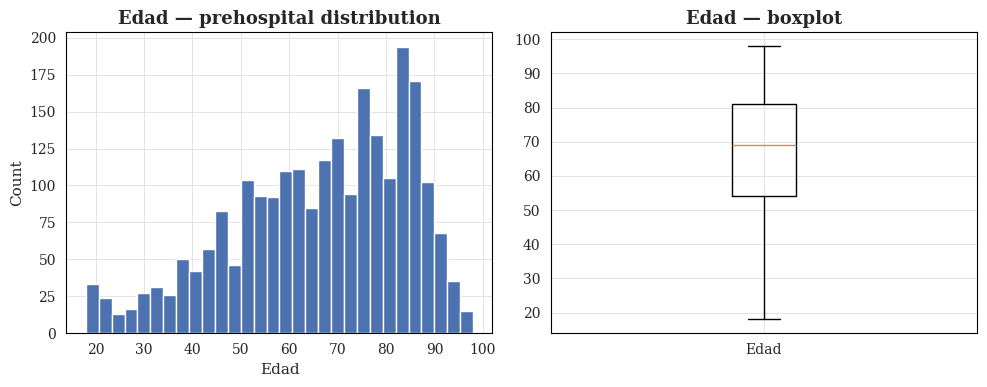

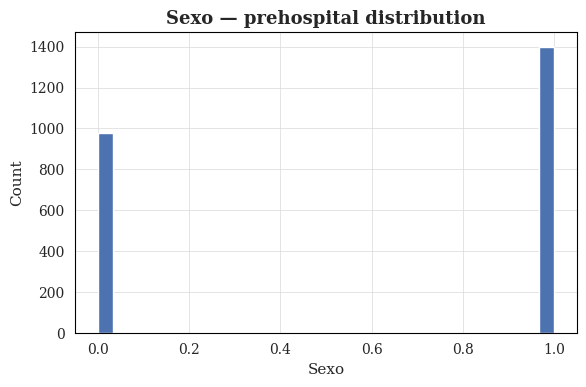

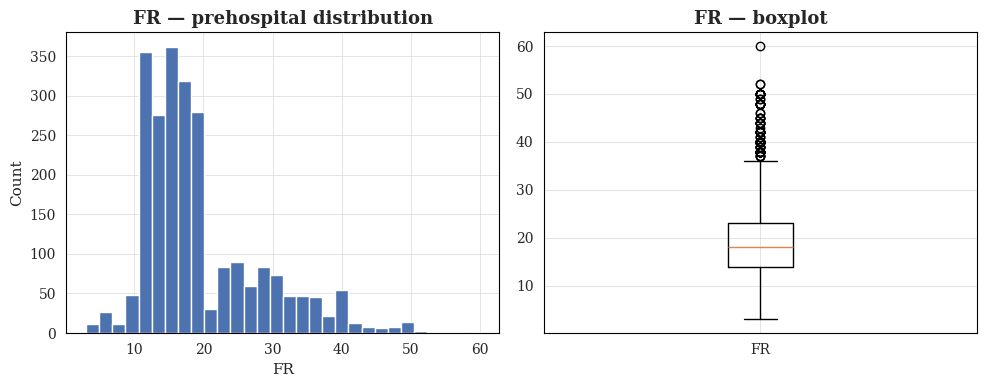

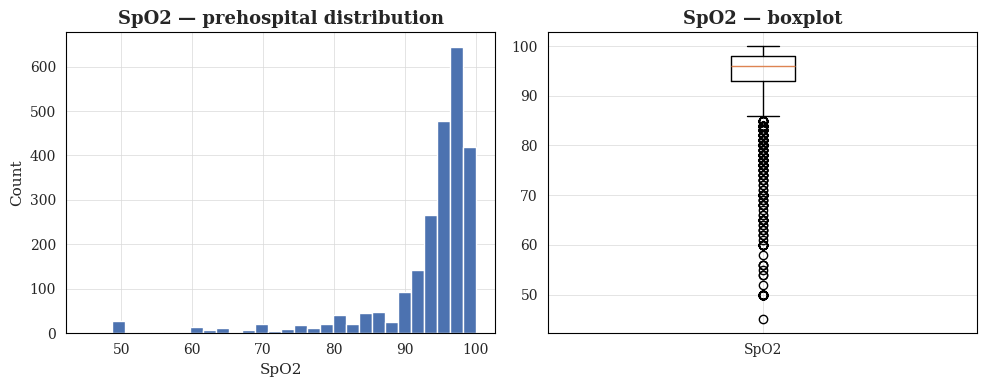

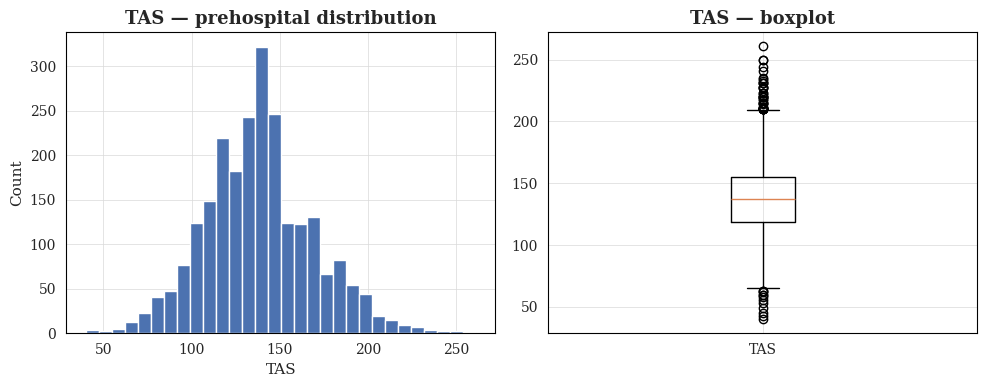

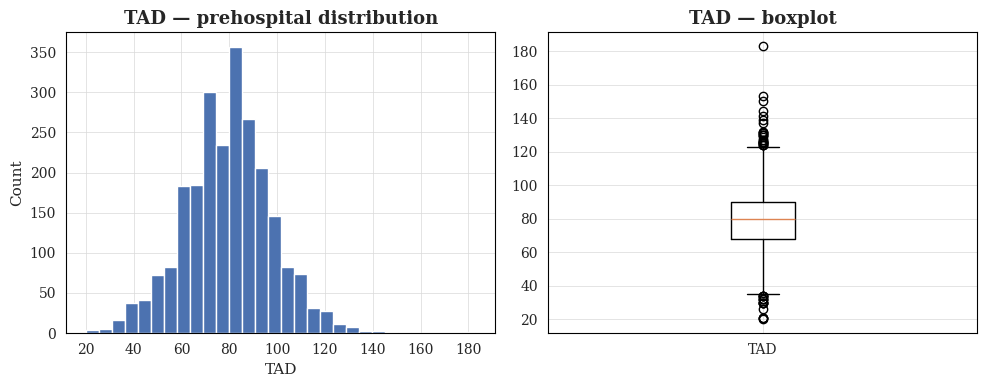

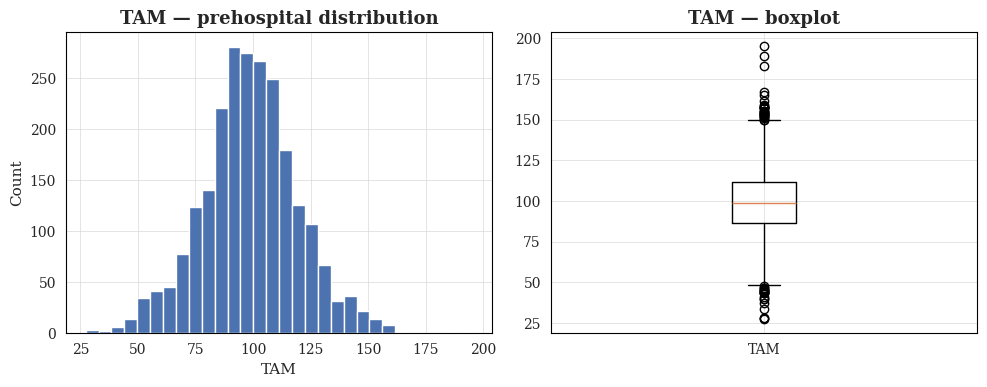

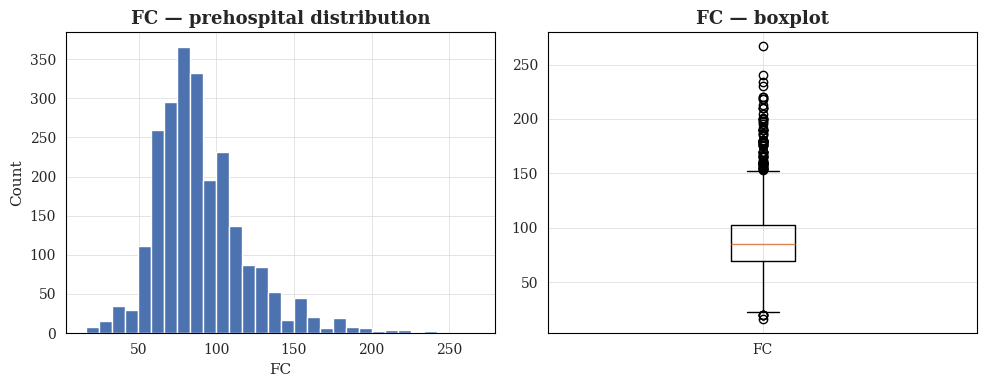

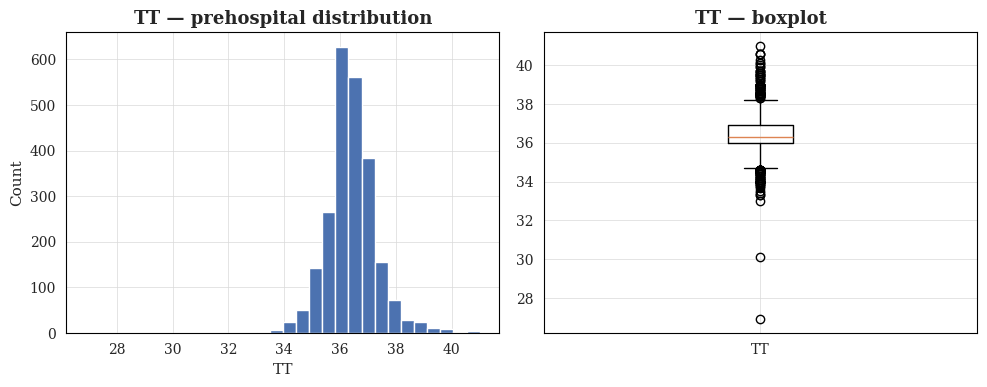

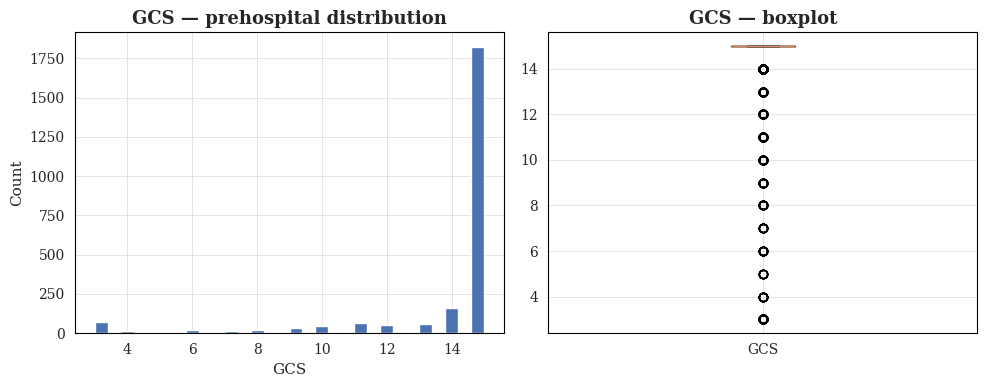

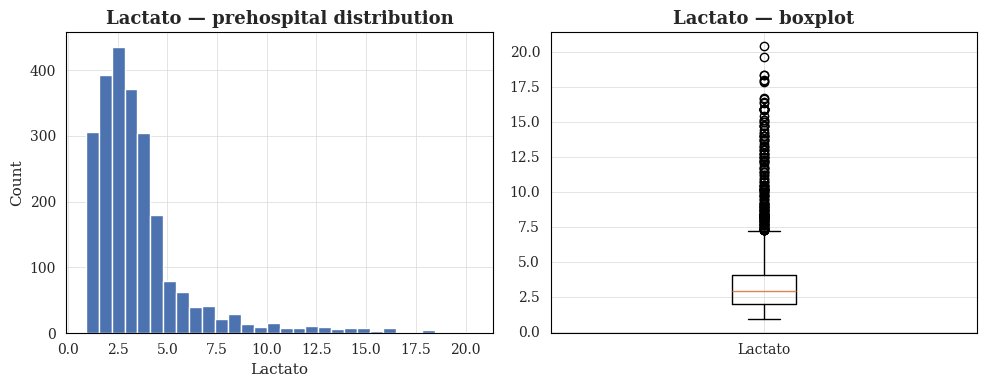

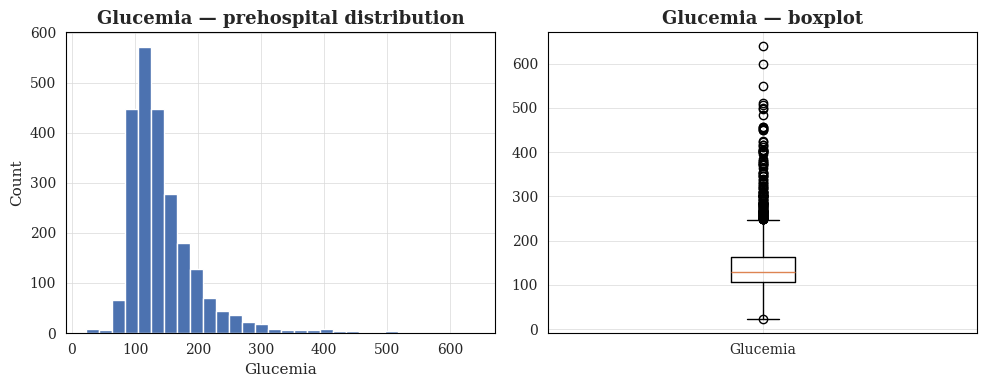

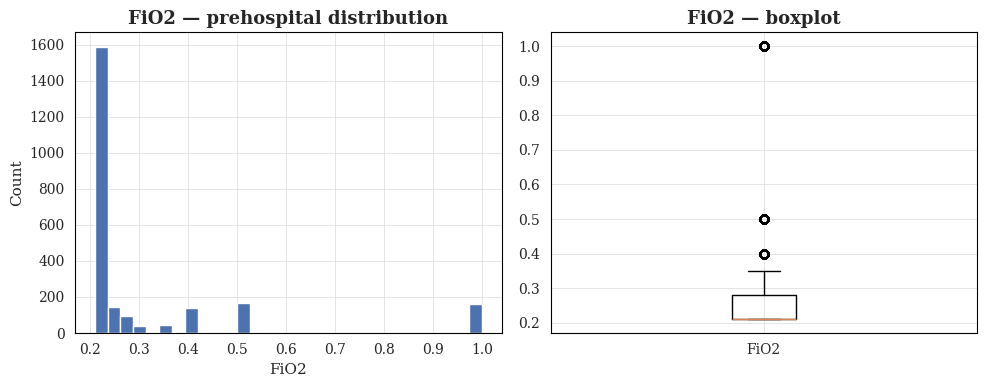

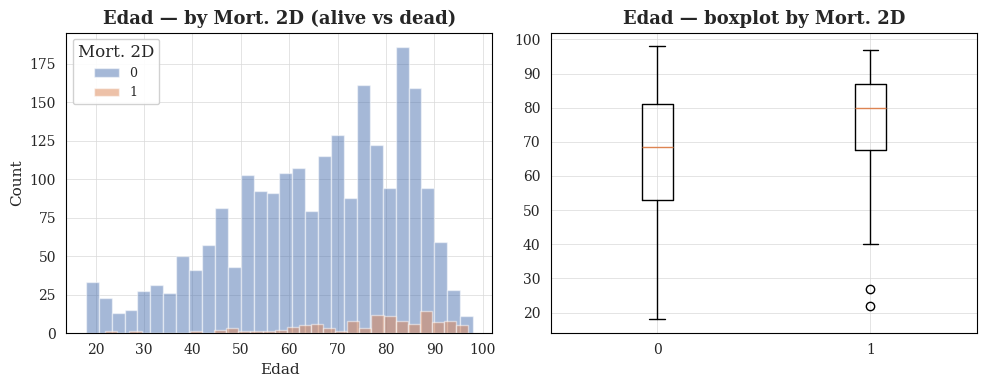

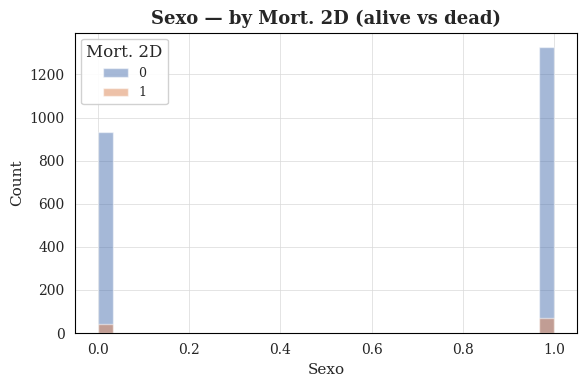

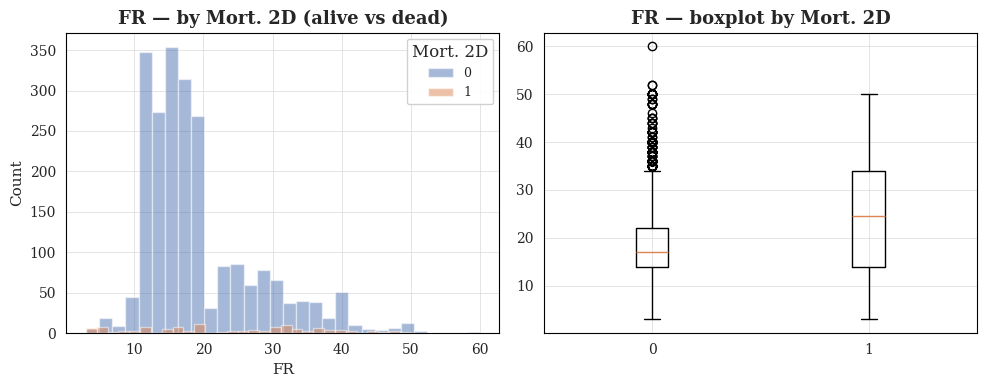

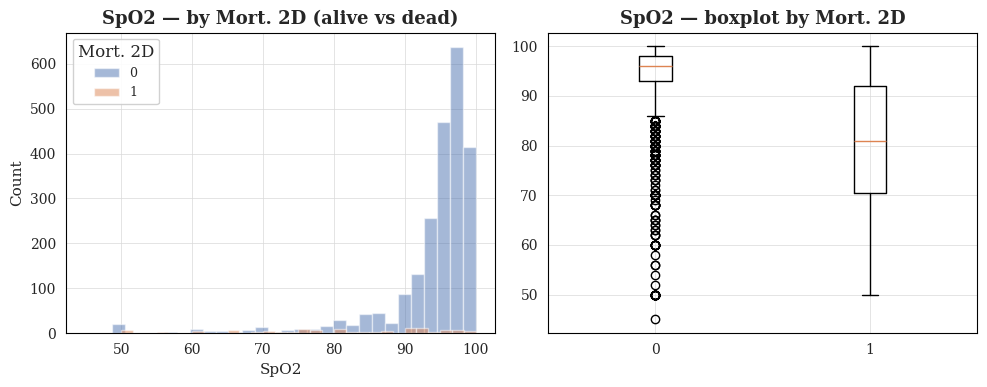

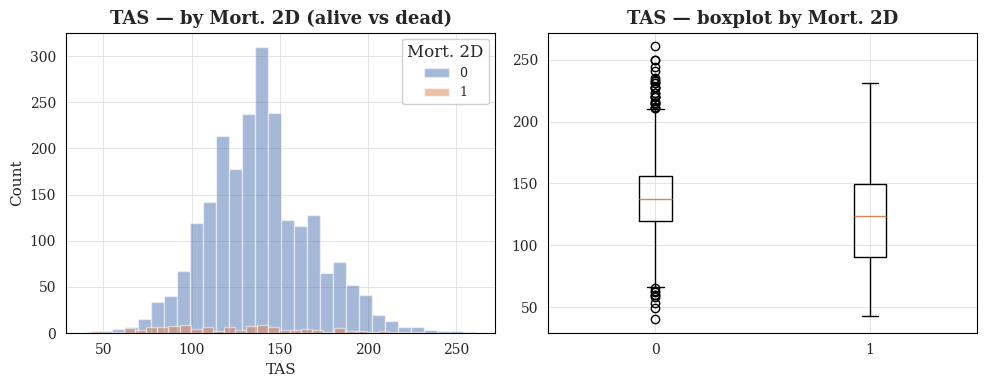

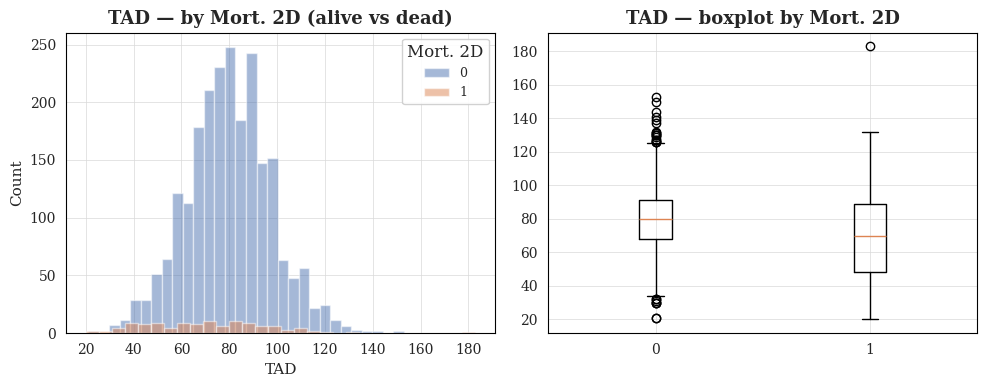

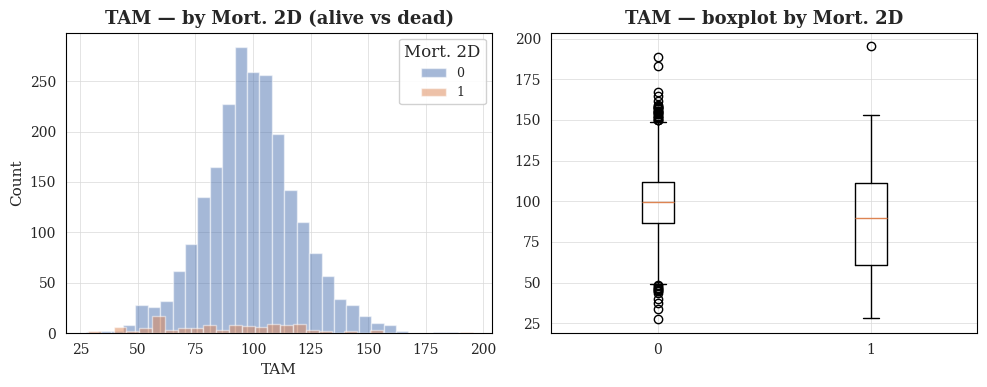

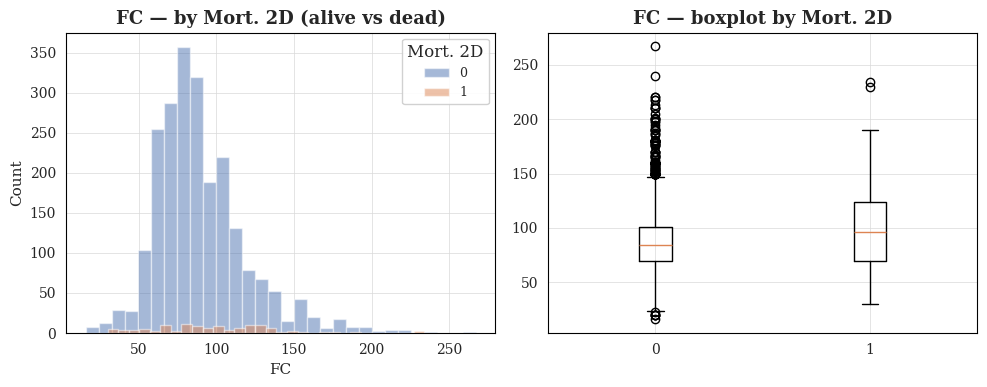

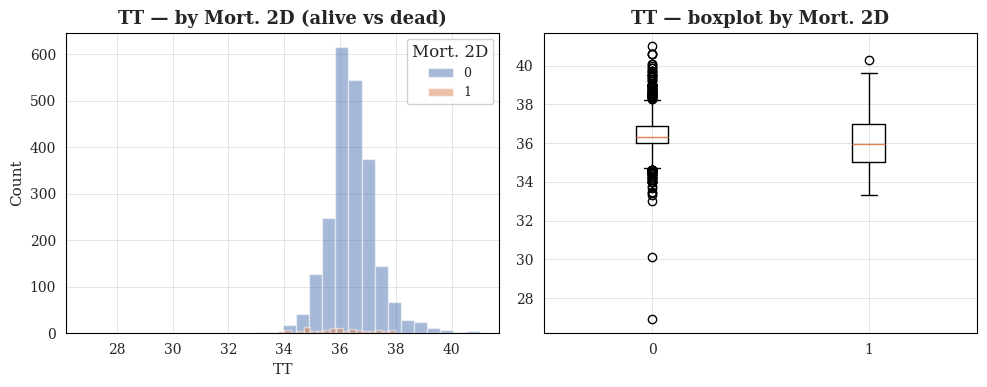

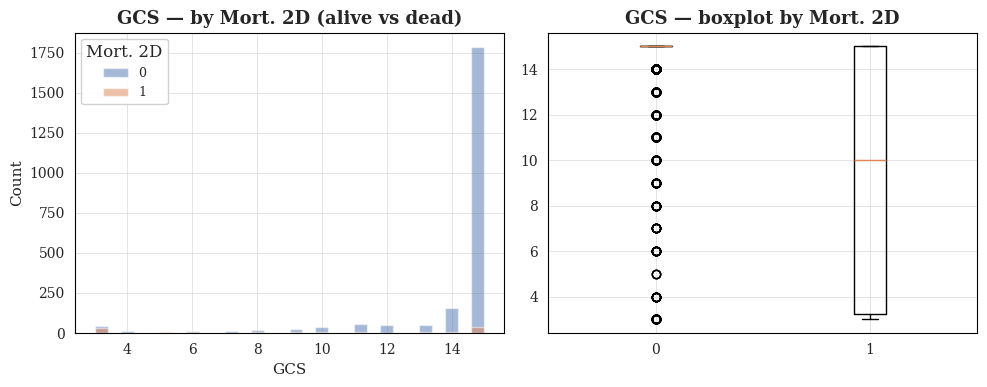

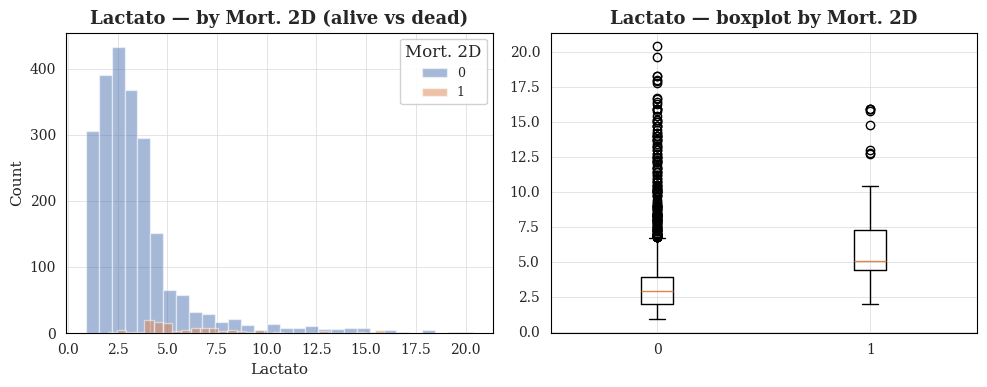

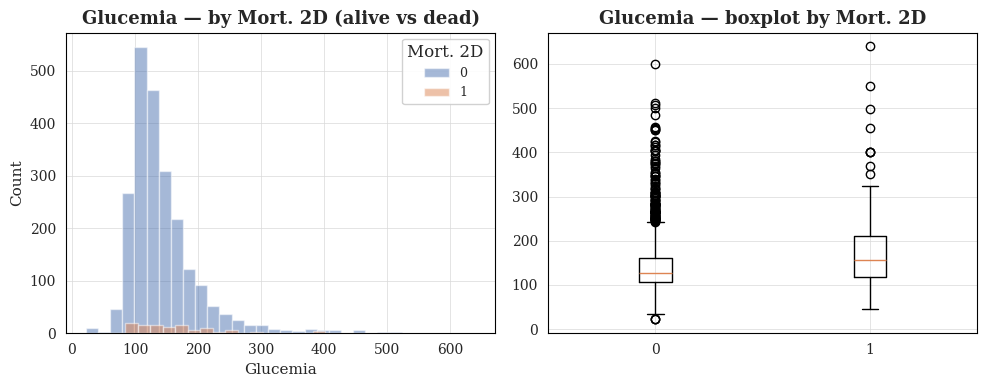

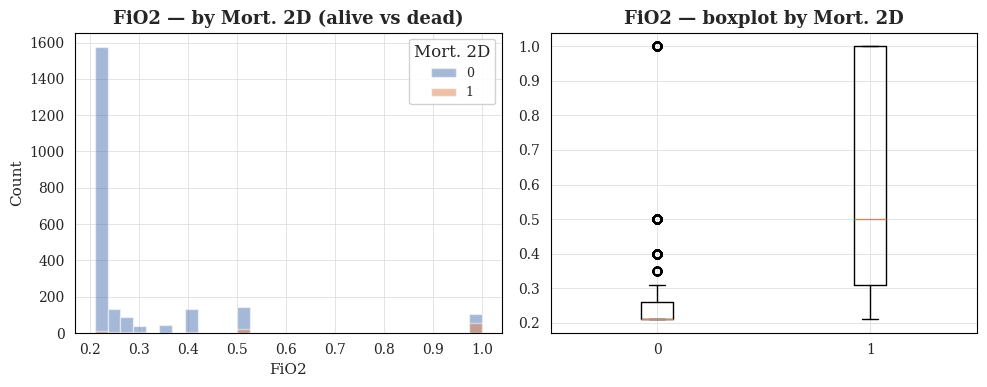

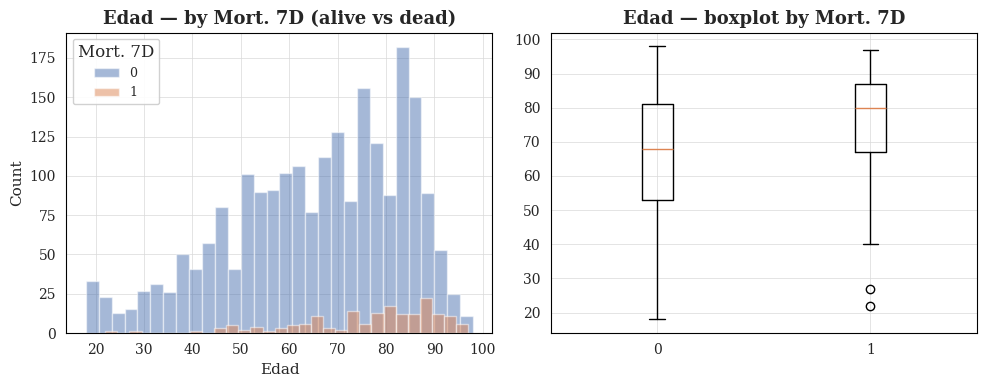

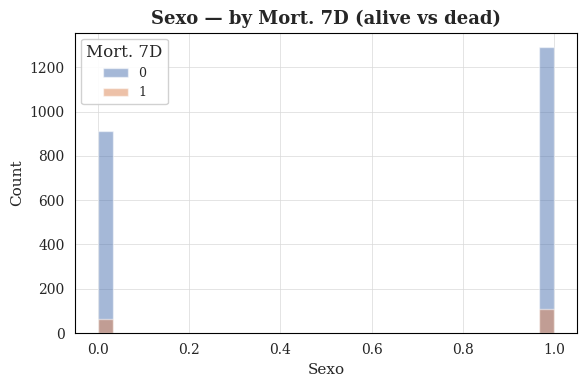

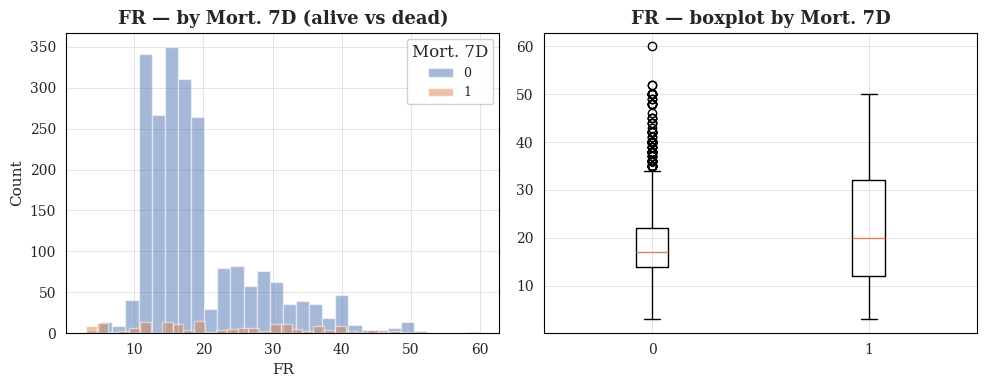

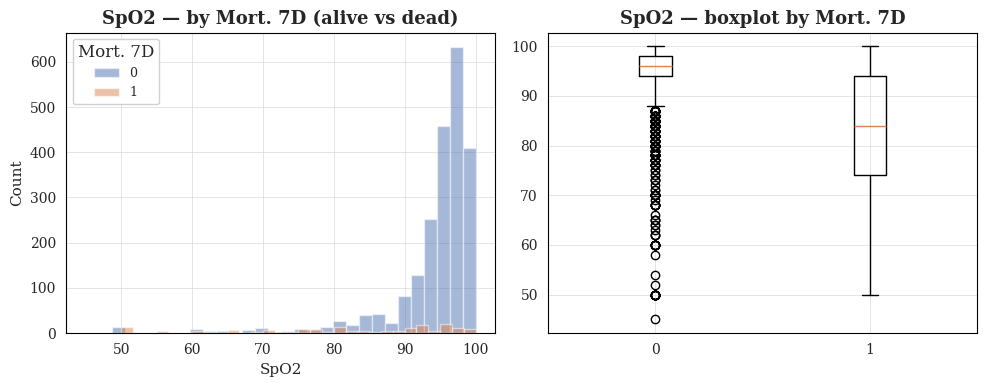

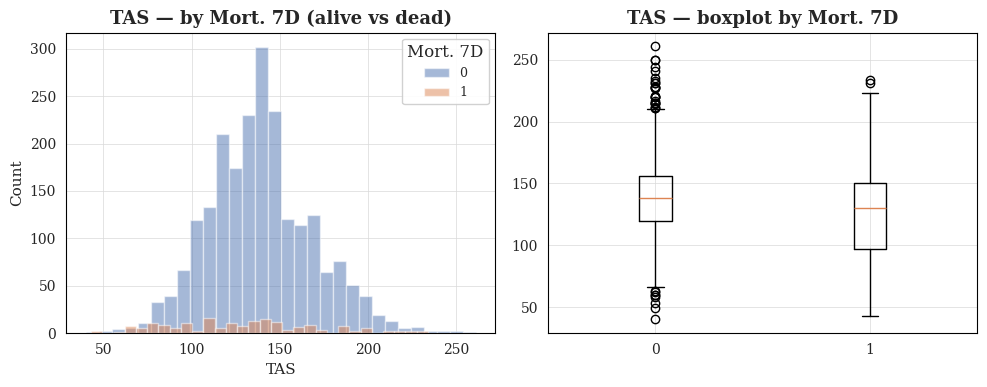

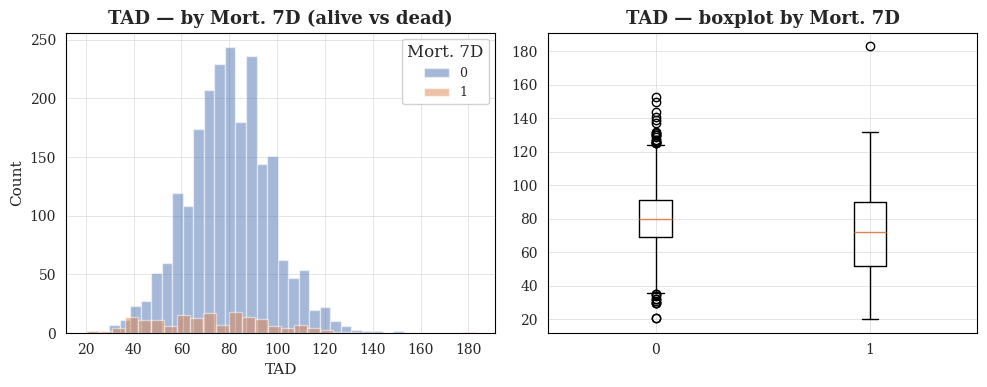

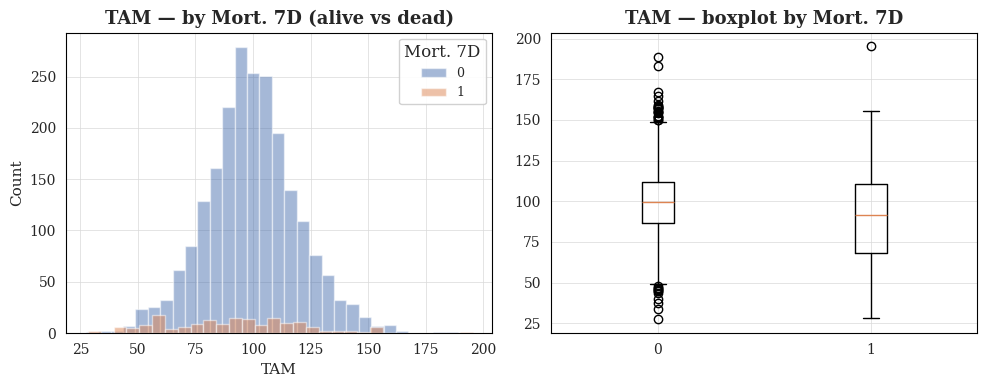

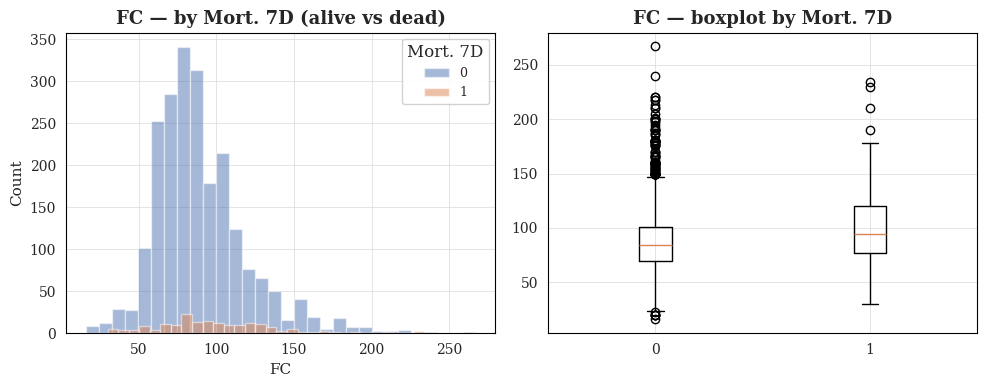

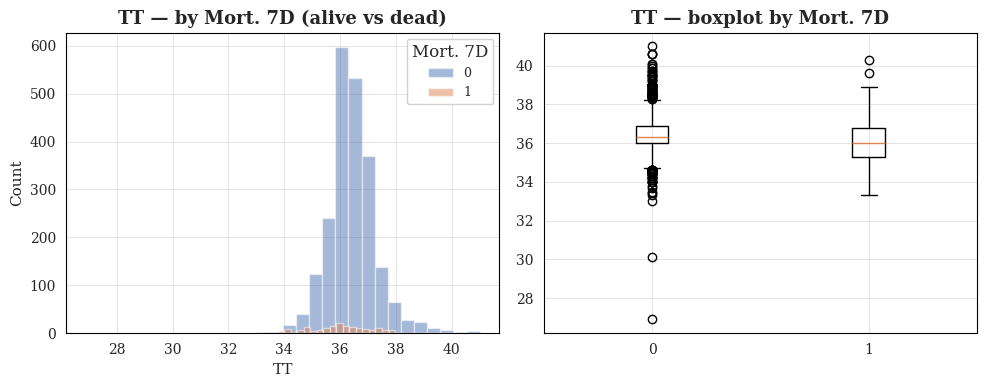

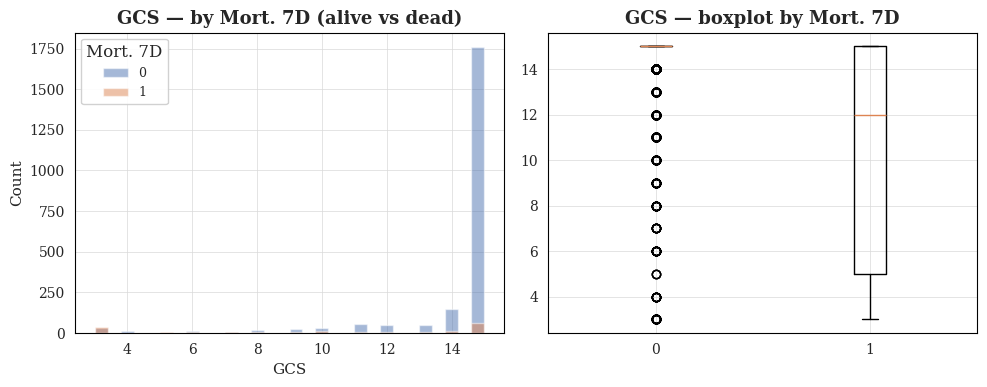

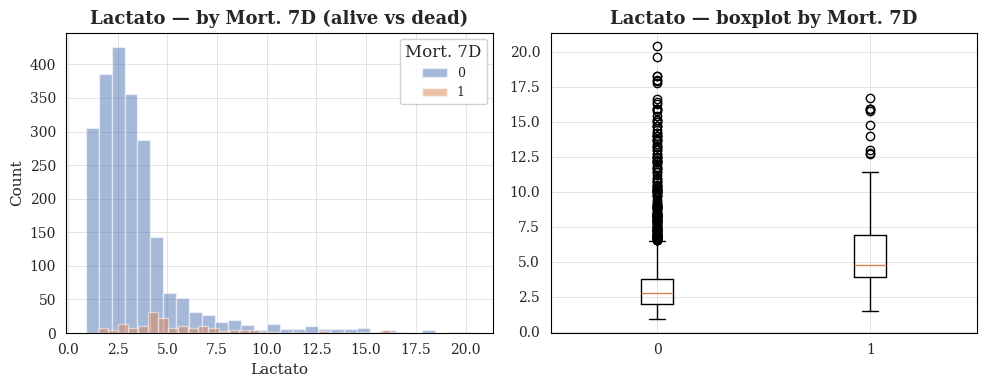

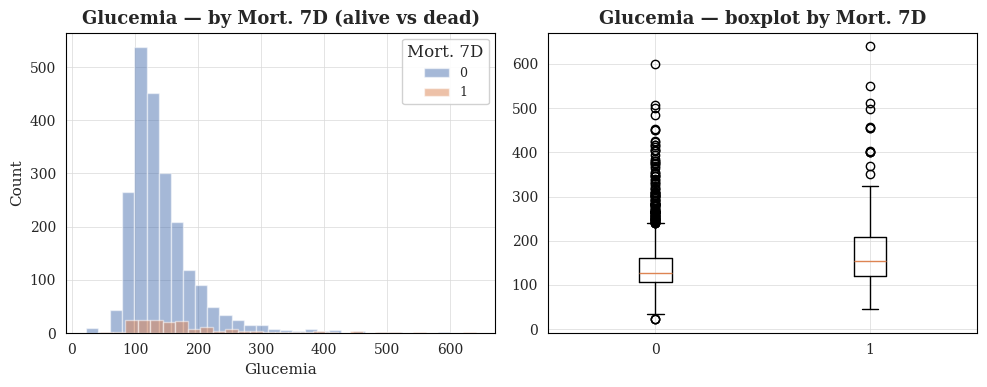

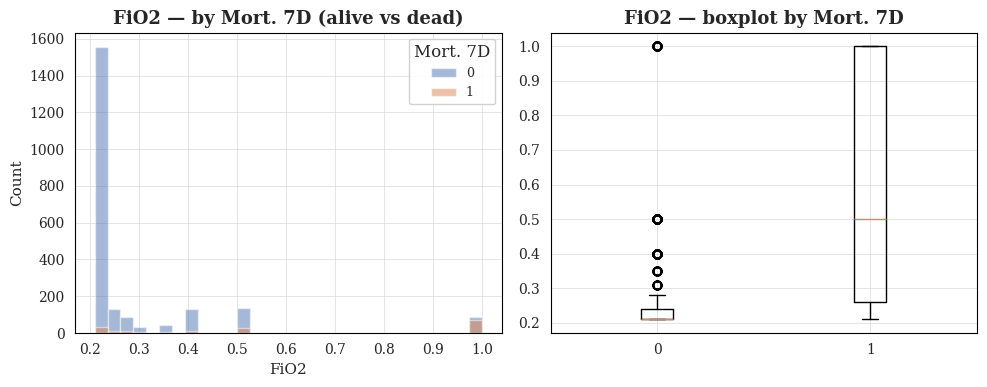

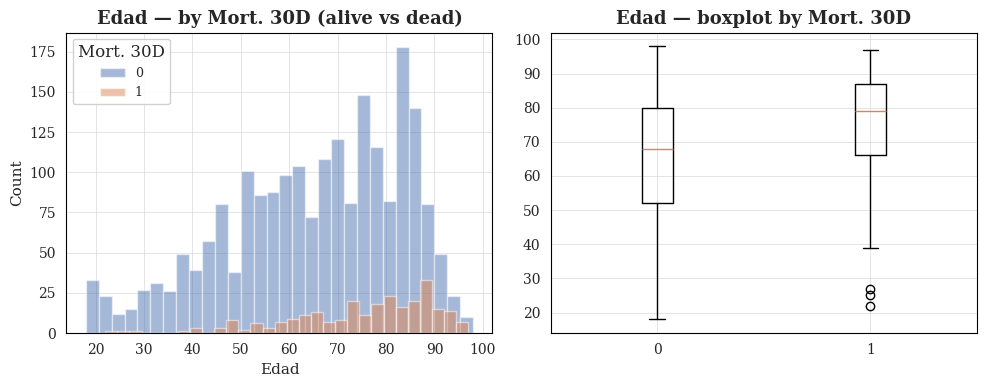

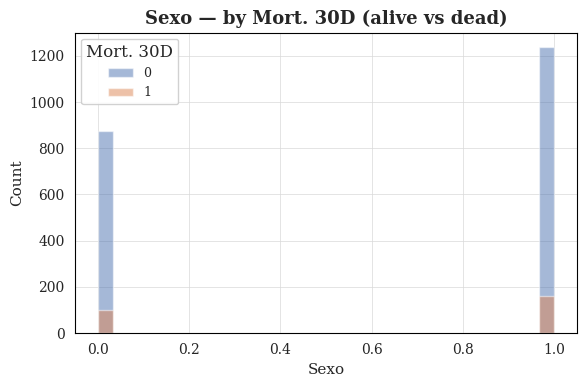

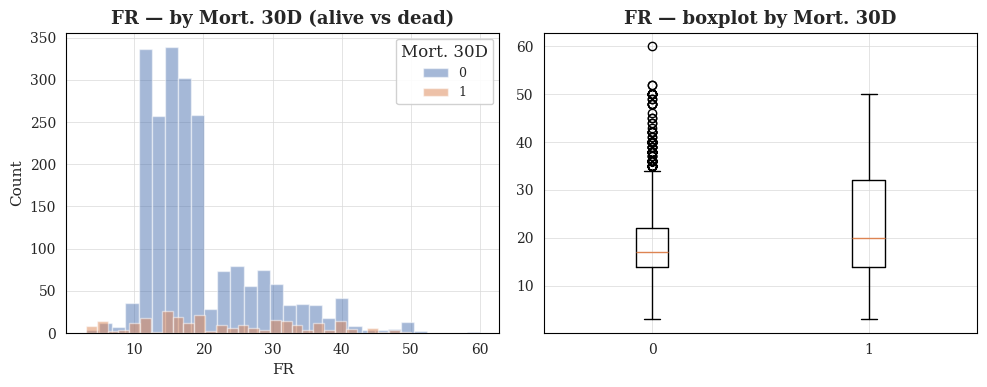

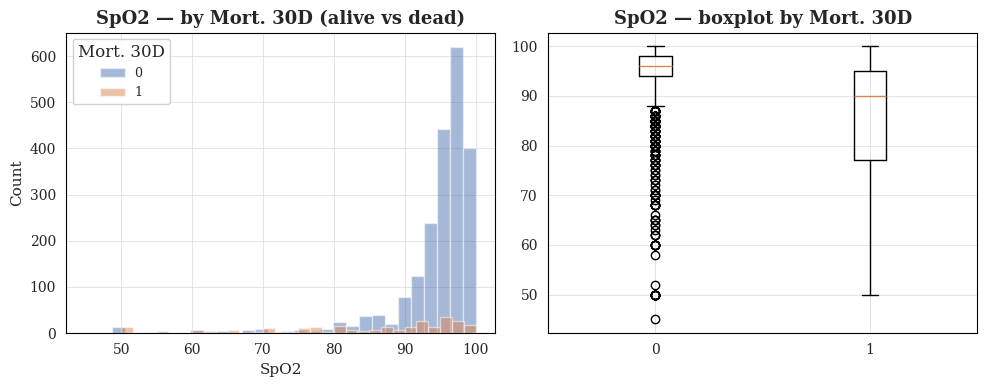

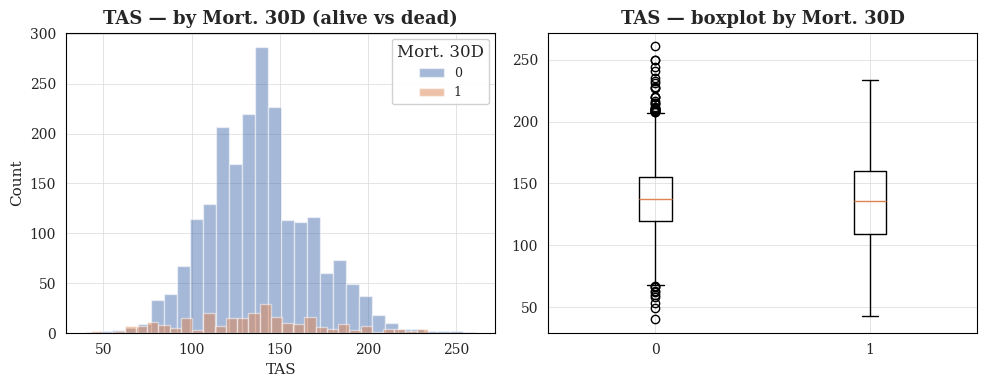

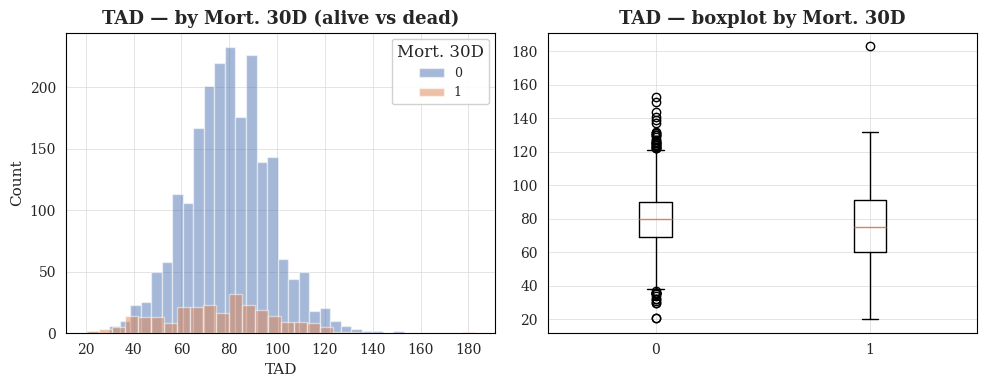

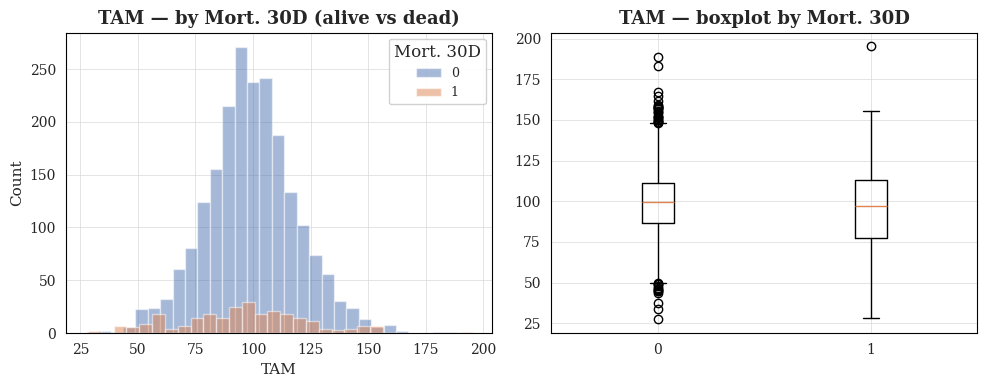

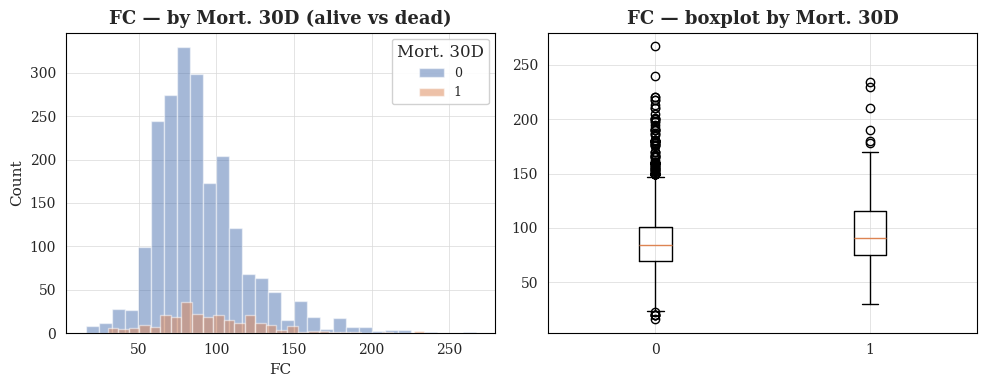

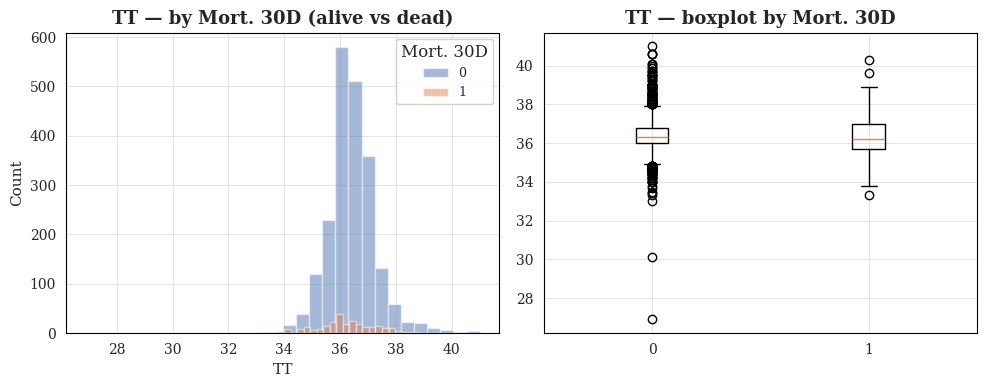

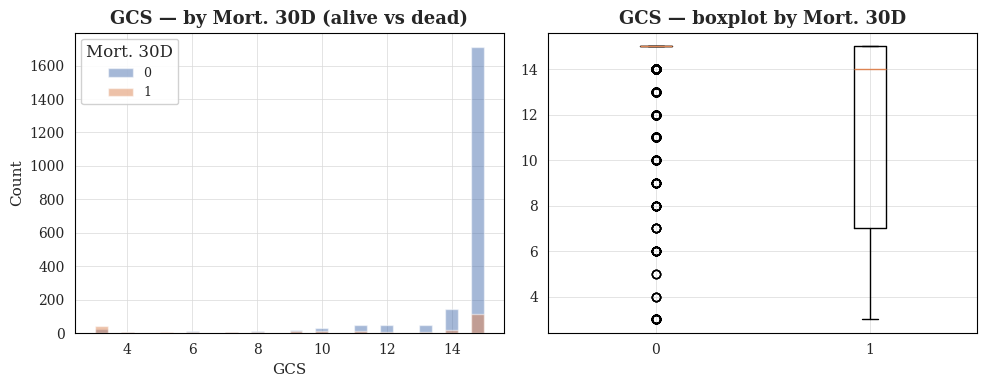

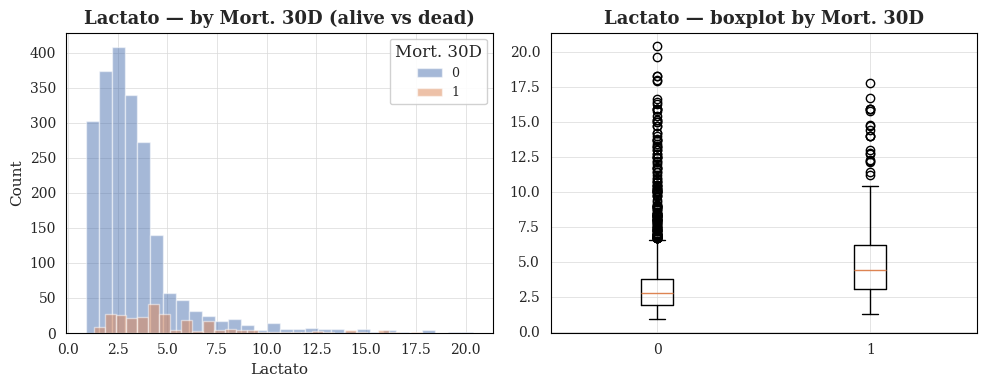

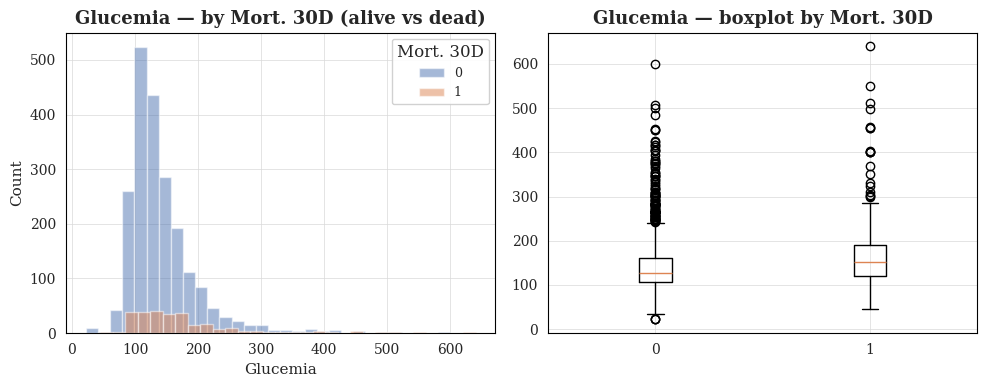

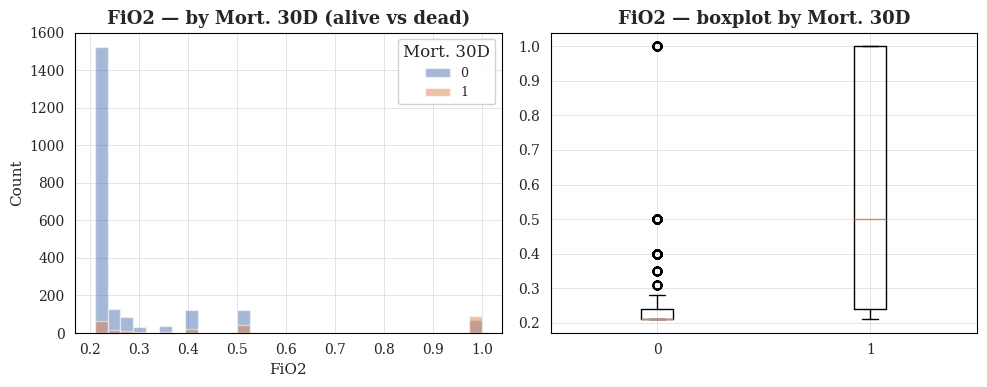

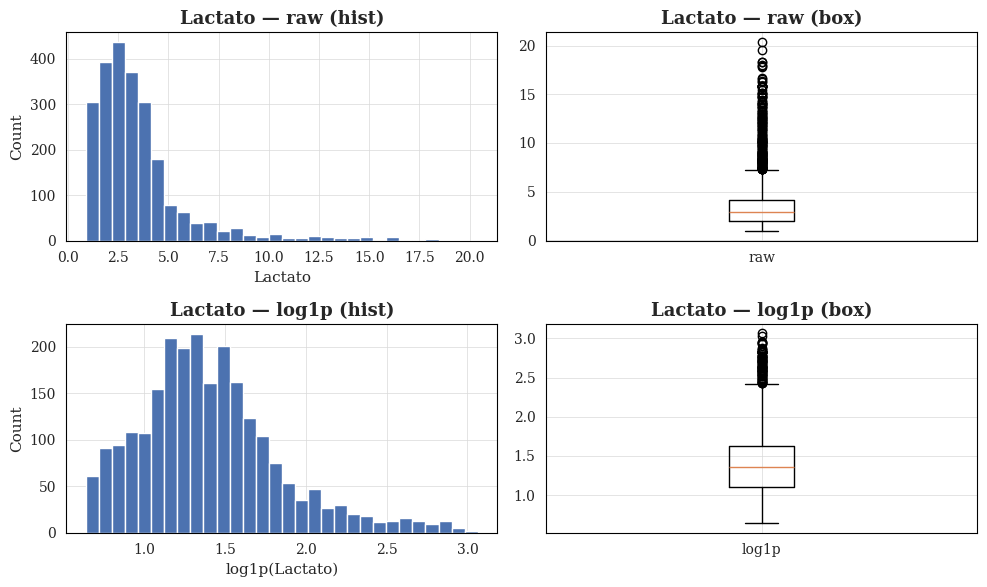

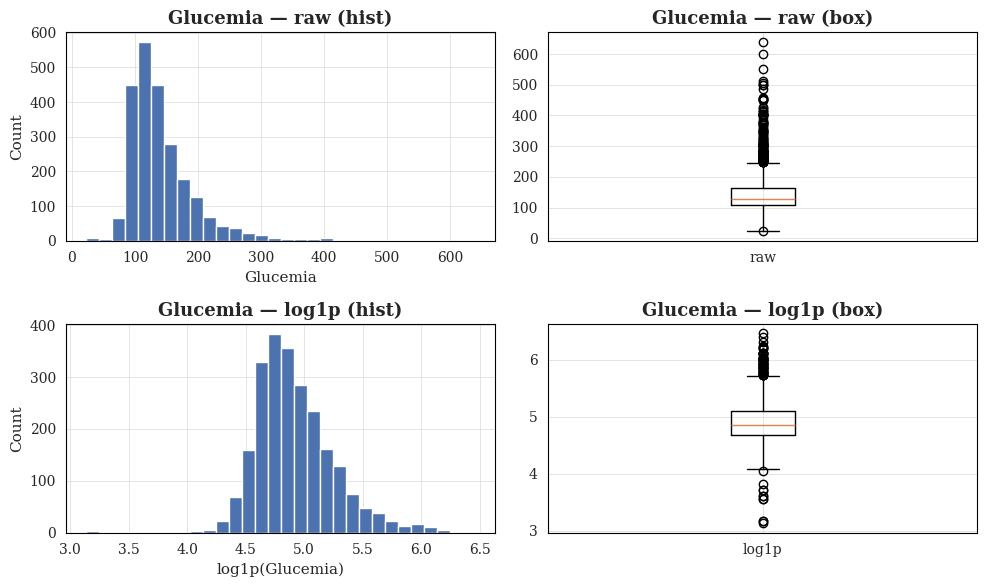

In [ ]:
# ----------------------------
# Key variables (prehospital)
# ----------------------------
pre_key = [c for c in ["Edad", "Sexo", "FR", "SpO2", "TAS", "TAD", "TAM",
                      "FC", "TT", "GCS", "Lactato", "Glucemia", "FiO2"]
           if c in df.columns]

# Boxplots only for truly numeric/continuous variables
pre_key_box = [c for c in pre_key if c not in ["Sexo"]]

# ----------------------------
# Helpers
# ----------------------------
def _num(s: pd.Series) -> pd.Series:
    return pd.to_numeric(s, errors="coerce")

# Defensive helper: mortality columns are already {0,1} after NB1.
# Retained as a safety net only.
def _to_event01(s: pd.Series) -> pd.Series:
    """Map common mortality coding to 0/1 when possible (1/2 -> 1/0)."""
    x = pd.to_numeric(s, errors="coerce")
    vals = set(x.dropna().unique().tolist())
    if vals.issubset({1, 2}):
        return (x == 1).astype("Int64")  # 1=dead, 0=alive
    if vals.issubset({0, 1}):
        return x.astype("Int64")
    return x

def plot_hist_and_box(df: pd.DataFrame, col: str, bins: int = 30, title: str = "",
                      save_path: Optional[str] = None) -> None:
    """One figure: histogram (left) + boxplot (right, if numeric)."""
    x = _num(df[col]).dropna()
    if x.empty:
        return

    has_box = col in pre_key_box
    fig, axes = plt.subplots(1, 2 if has_box else 1, figsize=(10 if has_box else 6, 4))
    if not isinstance(axes, np.ndarray):
        axes = np.array([axes])

    axh = axes[0]
    axh.hist(x, bins=bins)
    axh.set_title(title or f"{col} — distribution")
    axh.set_xlabel(col)
    axh.set_ylabel("Count")

    if has_box:
        axb = axes[1]
        axb.boxplot(x.values, showfliers=True)
        axb.set_title(f"{col} — boxplot")
        axb.set_xticks([1])
        axb.set_xticklabels([col])

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path)
    plt.show()

def plot_hist_and_box_by_group(df: pd.DataFrame, col: str, group: str,
                              bins: int = 30, title: str = "", max_groups: int = 6,
                              save_path: Optional[str] = None) -> None:
    """One figure: histogram overlay (left) + grouped boxplot (right, if numeric)."""
    if group not in df.columns:
        return

    x = _num(df[col])
    g = _to_event01(df[group])
    tmp = pd.DataFrame({col: x, group: g}).dropna()
    if tmp.empty:
        return

    levels = tmp[group].unique().tolist()
    if len(levels) == 0:
        return
    if len(levels) > max_groups:
        print(f"[skip] {col} by {group}: too many groups ({len(levels)} > {max_groups})")
        return

    # stable ordering
    try:
        levels = sorted(levels)
    except Exception:
        levels = sorted(levels, key=lambda v: str(v))

    has_box = col in pre_key_box
    fig, axes = plt.subplots(1, 2 if has_box else 1, figsize=(10 if has_box else 6, 4))
    if not isinstance(axes, np.ndarray):
        axes = np.array([axes])

    # Histogram overlay
    axh = axes[0]
    for lv in levels:
        xx = tmp.loc[tmp[group] == lv, col].dropna()
        if len(xx) == 0:
            continue
        axh.hist(xx, bins=bins, alpha=0.5, label=str(lv))
    axh.set_title(title or f"{col} — by {group} (overlay)")
    axh.set_xlabel(col)
    axh.set_ylabel("Count")
    axh.legend(title=group)

    # Grouped boxplot
    if has_box:
        axb = axes[1]
        data = [tmp.loc[tmp[group] == lv, col].dropna().values for lv in levels]
        axb.boxplot(data, showfliers=True)
        axb.set_title(f"{col} — boxplot by {group}")
        axb.set_xticks(range(1, len(levels) + 1))
        axb.set_xticklabels([str(lv) for lv in levels])

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path)
    plt.show()

def plot_raw_vs_log1p_hist_box(df: pd.DataFrame, col: str, bins: int = 30,
                               save_path: Optional[str] = None) -> None:
    """One figure (2x2): raw hist+box + log1p hist+box."""
    s = _num(df[col]).dropna()
    if s.empty:
        return
    s_log = np.log1p(s)

    fig, ax = plt.subplots(2, 2, figsize=(10, 6))

    ax[0, 0].hist(s, bins=bins)
    ax[0, 0].set_title(f"{col} — raw (hist)")
    ax[0, 0].set_xlabel(col)
    ax[0, 0].set_ylabel("Count")

    ax[0, 1].boxplot(s.values, showfliers=True)
    ax[0, 1].set_title(f"{col} — raw (box)")
    ax[0, 1].set_xticks([1])
    ax[0, 1].set_xticklabels(["raw"])

    ax[1, 0].hist(s_log, bins=bins)
    ax[1, 0].set_title(f"{col} — log1p (hist)")
    ax[1, 0].set_xlabel(f"log1p({col})")
    ax[1, 0].set_ylabel("Count")

    ax[1, 1].boxplot(s_log.values, showfliers=True)
    ax[1, 1].set_title(f"{col} — log1p (box)")
    ax[1, 1].set_xticks([1])
    ax[1, 1].set_xticklabels(["log1p"])

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path)
    plt.show()

# ----------------------------
# 1) Global: one figure per variable (hist + box)
# ----------------------------
for c in pre_key:
    _fname = os.path.join(NB2_OUTPUT_DIR, f"fig_09a_dist_{c.replace(chr(32), chr(95)).replace(chr(46), chr(0))}.png".replace(chr(0), ""))
    plot_hist_and_box(df, c, bins=30, title=f"{c} — prehospital distribution", save_path=_fname)

# ----------------------------
# 2) By mortality: one figure per variable per endpoint (hist overlay + box)
# ----------------------------
for mort in MORT_COLS:
    if mort not in df.columns:
        continue
    for c in pre_key:
        _c2 = c.replace(" ", "_").replace(".", "")
        _m2 = mort.replace(" ", "_").replace(".", "")
        _fname2 = os.path.join(NB2_OUTPUT_DIR, f"fig_09b_dist_{_c2}_by_{_m2}.png")
        plot_hist_and_box_by_group(df, c, group=mort, bins=30,
                                  title=f"{c} — by {mort} (alive vs dead)", save_path=_fname2)

# ----------------------------
# 3) Log1p comparison: one figure per variable (2x2)
# ----------------------------
for c in [x for x in ["Lactato", "Glucemia"] if x in df.columns]:
    _fname3 = os.path.join(NB2_OUTPUT_DIR, f"fig_09c_log1p_{c}.png")
    plot_raw_vs_log1p_hist_box(df, c, bins=30, save_path=_fname3)



## **10. Correlation analysis (Spearman)**

Spearman rank correlation is used instead of Pearson because:
- It is robust to non-normality and skewed distributions (common in clinical vital signs).
- It captures monotonic relationships, not just linear ones.

The top 15 absolute correlations are reported alongside a heatmap to identify variable pairs with high redundancy (candidates for VIF-based removal in **NB4**).

### Output

| Output | Type | Description |
|--------|------|-------------|
| Table | `pd.DataFrame` | Top 15 variable pairs by |ρ| |
| Heatmap | plot | Full Spearman correlation matrix for baseline numeric variables |


### Top absolute Spearman correlations (baseline numeric)

,var1,var2,spearman_r
0,TAD,TAM,0.932017
1,TAS,TAM,0.903886
2,TAS,TAD,0.702850
3,Edad,SpO2,-0.340942
4,GCS,Lactato,-0.268441
5,FR,SpO2,-0.247755
6,Edad,Glucemia,0.246549
7,SpO2,GCS,0.234723
8,Lactato,Glucemia,0.222165
9,FR,FC,0.216615


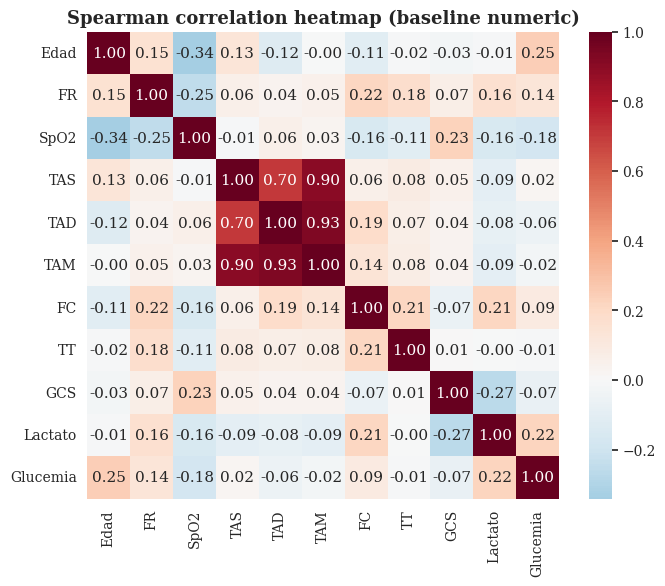

In [ ]:
BASELINE_NUM = [c for c in ["Edad", "FR", "SpO2", "TAS", "TAD", "TAM",
                            "FC", "TT", "GCS", "Lactato", "Glucemia"]
               if c in df.columns]  # FiO2 not included in this baseline set.

corr_cols = [c for c in BASELINE_NUM if c in df.columns]

if len(corr_cols) >= 3:
    corr = df[corr_cols].corr(method="spearman", numeric_only=True)

    # Extract top pairs
    pairs = []
    cols = corr.columns
    for i in range(len(cols)):
        for j in range(i + 1, len(cols)):
            pairs.append((cols[i], cols[j], corr.iloc[i, j]))
    pairs = sorted(pairs, key=lambda x: abs(x[2]), reverse=True)
    top = pd.DataFrame(pairs[:15], columns=["var1", "var2", "spearman_r"])

    display(Markdown("### Top absolute Spearman correlations (baseline numeric)"))
    display(top)
    top.to_csv(os.path.join(NB2_OUTPUT_DIR, "tbl_10_spearman_top_pairs.csv"), index=False)

    plt.figure(figsize=(7, 6))
    sns.heatmap(corr, center=0, annot=True, fmt=".2f", cmap="RdBu_r")
    plt.title("Spearman correlation heatmap (baseline numeric)")
    plt.tight_layout()
    plt.savefig(os.path.join(NB2_OUTPUT_DIR, "fig_10_spearman_heatmap.png"))
    plt.show()
else:
    display(Markdown("⚠️ Not enough baseline numeric columns for correlation heatmap."))

## **11. K-Means clustering (numeric baseline)**

K-Means is applied to the baseline numeric prehospital variables to identify coarse patient subgroups based on vital signs and lab values.

**Preprocessing** (applied only for clustering, not saved):
1. Median imputation for missing numeric values.
2. Z-score standardisation — necessary because variables have different units (mmHg, °C, %, etc.) and K-Means uses Euclidean distance.

**Model selection**:
- Grid search over k ∈ {2, 3, 4, 5, 6, 7}.
- Two criteria: **elbow method** (inertia) and **silhouette score** (cluster compactness + separation).

**Validation**:
- Cluster quality metrics: silhouette, Calinski-Harabasz, Davies-Bouldin.
- **Stability**: the chosen k=3 model is re-run with 9 different random seeds; Adjusted Rand Index (ARI) vs the reference seed measures reproducibility.
- **Clinical interpretation**: mean/median profiles per cluster, PCA 2D scatter, signature heatmap.

### Parameters

| Parameter | Value | Justification |
|-----------|-------|---------------|
| `k_grid` | `range(2, 8)` | Covers the clinically plausible range of patient subgroups |
| `k_opt` | `3` | Selected from elbow + silhouette (confirmed in original NB2) |
| `n_init` | `50` | High value ensures convergence to a good local optimum |
| `RANDOM_STATE` | `42` | Reproducibility |

### Output

| Output | Type | Description |
|--------|------|-------------|
| Elbow plot | plot | Inertia vs k |
| Silhouette plot | plot | Silhouette score vs k |
| Metrics table | `pd.DataFrame` | Silhouette, CH, DB for k=3 |
| Cluster sizes | `pd.Series` | Number of patients per cluster |
| Mean profiles | `pd.DataFrame` | Mean of baseline numerics per cluster |
| PCA scatter | plot | 2D projection coloured by cluster |
| Signature heatmap | plot | Median z-scores per cluster per variable |
| Stability table | `pd.DataFrame` | ARI vs reference across 9 seeds |

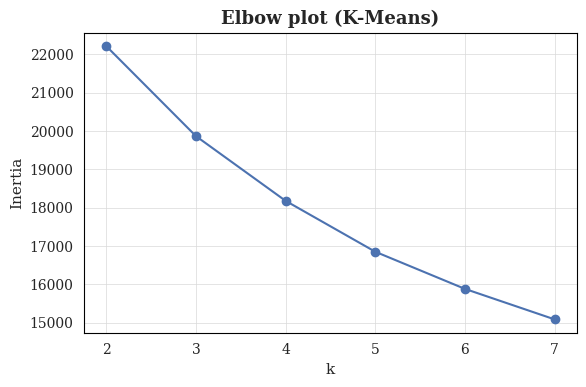

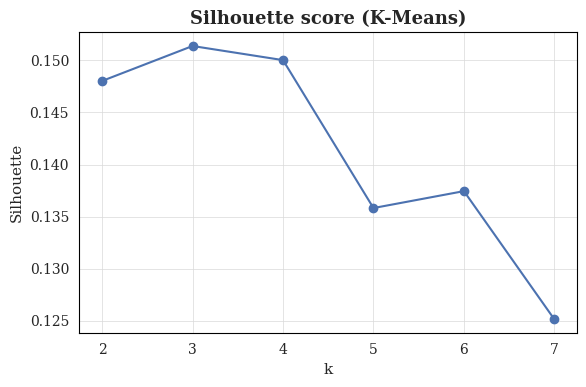

### K-Means metrics (k=3)

,silhouette,calinski_harabasz,davies_bouldin
0,0.151384,374.520067,1.909374


### Cluster sizes

,count
cluster_kmeans_k3,
0,1161
1,1013
2,202


### Mean profile by cluster

,Edad,FR,SpO2,TAS,TAD,TAM,FC,TT,GCS,Lactato,Glucemia
cluster_kmeans_k3,,,,,,,,,,,
0,63.20,18.01,95.67,119.89,68.92,85.91,82.96,36.27,14.55,3.15,134.26
1,68.89,20.85,93.83,162.42,93.54,116.50,93.51,36.51,14.34,3.23,145.05
2,68.93,22.79,77.37,119.41,67.65,84.77,109.75,36.33,8.20,7.44,195.89


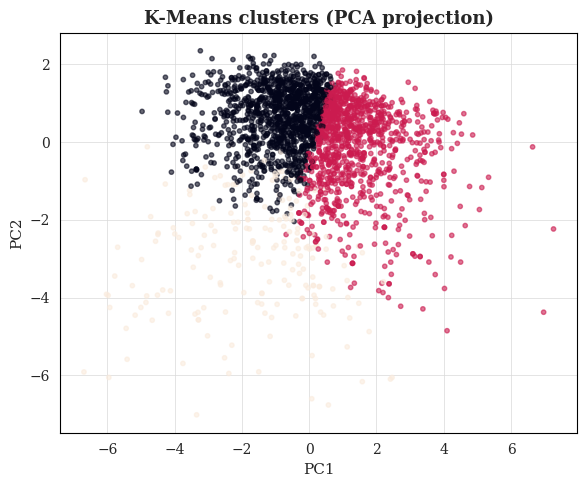

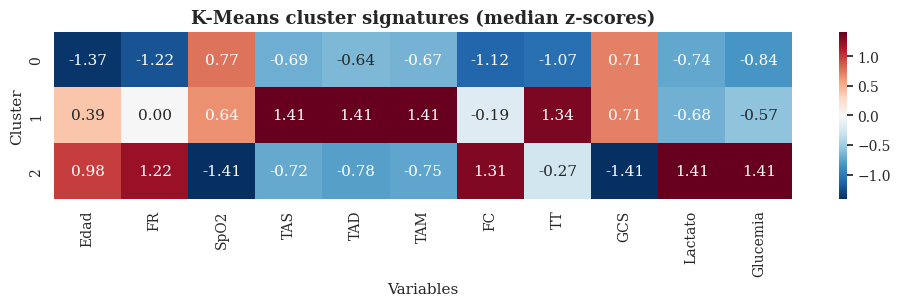

### K-Means stability (ARI vs seed=42)

,seed,ARI_vs_ref
0,0,1.0
1,1,1.0
2,2,1.0
3,3,1.0
4,4,1.0
5,10,1.0
6,20,1.0
7,42,1.0
8,99,1.0


In [ ]:
X_km = df[BASELINE_NUM].copy()
X_imp = SimpleImputer(strategy="median").fit_transform(X_km)
X_scaled = StandardScaler().fit_transform(X_imp)

# --- Model selection ---
k_grid = range(2, 8)
sils, inertias = [], []
for k in k_grid:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=50)
    lab = km.fit_predict(X_scaled)
    sils.append(silhouette_score(X_scaled, lab))
    inertias.append(km.inertia_)

plt.figure(figsize=(6, 4))
plt.plot(list(k_grid), inertias, marker="o")
plt.title("Elbow plot (K-Means)")
plt.xlabel("k")
plt.ylabel("Inertia")
plt.tight_layout()
plt.savefig(os.path.join(NB2_OUTPUT_DIR, "fig_11a_kmeans_elbow.png"))
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(list(k_grid), sils, marker="o")
plt.title("Silhouette score (K-Means)")
plt.xlabel("k")
plt.ylabel("Silhouette")
plt.tight_layout()
plt.savefig(os.path.join(NB2_OUTPUT_DIR, "fig_11b_kmeans_silhouette.png"))
plt.show()

# --- Fit chosen k ---
k_opt = 3
km_final = KMeans(n_clusters=k_opt, random_state=RANDOM_STATE, n_init=50)
df["cluster_kmeans_k3"] = km_final.fit_predict(X_scaled)

lab = df["cluster_kmeans_k3"].values
metrics = {
    "silhouette":        float(silhouette_score(X_scaled, lab)),
    "calinski_harabasz": float(calinski_harabasz_score(X_scaled, lab)),
    "davies_bouldin":    float(davies_bouldin_score(X_scaled, lab)),
}
km_metrics_df = pd.DataFrame([metrics])
display(Markdown("### K-Means metrics (k=3)"))
display(km_metrics_df)
km_metrics_df.to_csv(os.path.join(NB2_OUTPUT_DIR, "tbl_11a_kmeans_metrics.csv"), index=False)

cluster_sizes_df = df["cluster_kmeans_k3"].value_counts().sort_index().rename("count").to_frame()
display(Markdown("### Cluster sizes"))
display(cluster_sizes_df)
cluster_sizes_df.to_csv(os.path.join(NB2_OUTPUT_DIR, "tbl_11b_kmeans_cluster_sizes.csv"))

cluster_profile_df = df.groupby("cluster_kmeans_k3")[BASELINE_NUM].mean().round(2)
display(Markdown("### Mean profile by cluster"))
display(cluster_profile_df)
cluster_profile_df.to_csv(os.path.join(NB2_OUTPUT_DIR, "tbl_11c_kmeans_profiles.csv"))

# --- PCA 2D scatter ---
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)
plt.figure(figsize=(6, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=lab, alpha=0.6, s=10)
plt.title("K-Means clusters (PCA projection)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.savefig(os.path.join(NB2_OUTPUT_DIR, "fig_11c_kmeans_pca_scatter.png"))
plt.show()

# --- Signature heatmap ---
med = df.groupby("cluster_kmeans_k3")[BASELINE_NUM].median()
sig = (med - med.mean()) / med.std(ddof=0)
sig = sig.fillna(0)

plt.figure(figsize=(10, 3.2))
sns.heatmap(sig, center=0, annot=True, fmt=".2f", cmap="RdBu_r")
plt.title("K-Means cluster signatures (median z-scores)")
plt.ylabel("Cluster")
plt.xlabel("Variables")
plt.tight_layout()
plt.savefig(os.path.join(NB2_OUTPUT_DIR, "fig_11d_kmeans_signatures.png"))
plt.show()

# --- Stability (ARI across seeds) ---
seeds = [0, 1, 2, 3, 4, 10, 20, 42, 99]
ref = df["cluster_kmeans_k3"].values
aris = []
for s in seeds:
    lab_s = KMeans(n_clusters=3, random_state=s, n_init=50).fit_predict(X_scaled)
    aris.append(adjusted_rand_score(ref, lab_s))

stability_df = pd.DataFrame({"seed": seeds, "ARI_vs_ref": aris})
display(Markdown("### K-Means stability (ARI vs seed=42)"))
display(stability_df)
stability_df.to_csv(os.path.join(NB2_OUTPUT_DIR, "tbl_11d_kmeans_stability.csv"), index=False)

## **12. FAMD + Ward hierarchical clustering (mixed data)**

K-Means only handles numeric variables. To cluster on the full prehospital feature set (numeric vitals + binary intervention flags), we use **Factor Analysis of Mixed Data (FAMD)**, which:

1. Applies PCA-like scaling to continuous variables and MCA-like encoding to categorical variables.
2. Projects all variables into a shared latent space where Euclidean distances are meaningful.

Once projected, **Ward's agglomerative clustering** is applied to the FAMD coordinates. Ward minimises within-cluster variance at each merge step, producing compact, spherical clusters.

### Feature sets

Two clustering configurations are computed to compare the effect of including intervention variables:

| Set | Variables | Rationale |
|-----|-----------|-----------|
| **PRE** (vitals only) | Edad, Sexo, FR, SpO2, TAS, TAD, TAM, FC, TT, GCS, Lactato, Glucemia | Core prehospital vital signs and labs |
| **ALL** (vitals + interventions) | PRE + O2 sup., Gafas, Venturi, Resrv., Nebul., VNI, IOT, VAD, VM, MAVA, TTE | Adds prehospital intervention flags |

### Function: `famd_ward_pipeline()`

| Parameter | Type | Default | Description |
|-----------|------|---------|-------------|
| `df` | `pd.DataFrame` | — | Input data |
| `features` | `Sequence[str]` | — | Columns to use |
| `k` | `int` | `3` | Number of clusters |
| `n_components` | `int` | `12` | FAMD latent dimensions |
| `random_state` | `int` | `42` | Seed |
| `low_card_as_cat` | `bool` | `True` | Reclassify numeric columns with ≤ `low_card_threshold` unique values as categorical |
| `low_card_threshold` | `int` | `3` | Cardinality threshold for reclassification |
| **Returns** | `Dict` | | Keys: `features`, `X_f` (FAMD coords), `Z` (linkage matrix), `labels`, `metrics` |

### Output

| Output | Type | Description |
|--------|------|-------------|
| Metrics table | `pd.DataFrame` | Silhouette, CH, DB for PRE and ALL sets |
| FAMD scatter (×2) | plot | 2D projection coloured by cluster |
| Ward dendrogram (×2) | plot | Hierarchical structure |
| Mortality bar chart | plot | Mortality rate by cluster (ALL set) |

### FAMD + Ward metrics

,set,silhouette,calinski_harabasz,davies_bouldin
0,PRE,0.124491,257.634164,2.379800
1,ALL,0.435363,726.473499,1.616947


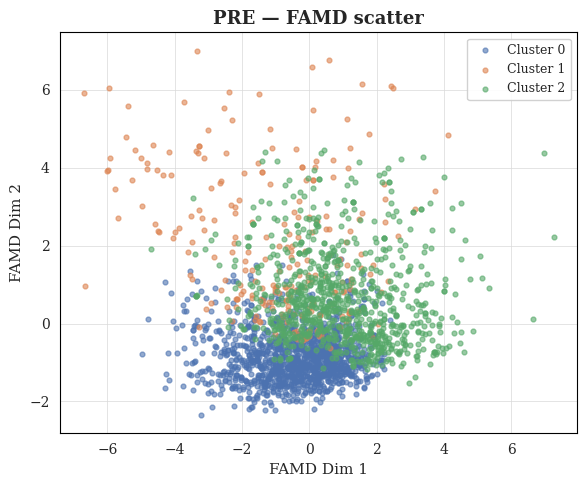

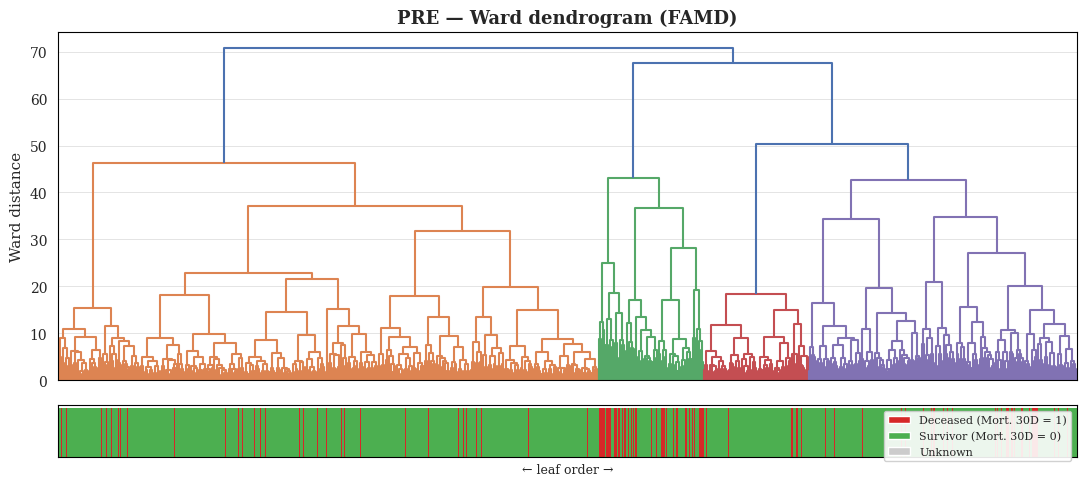

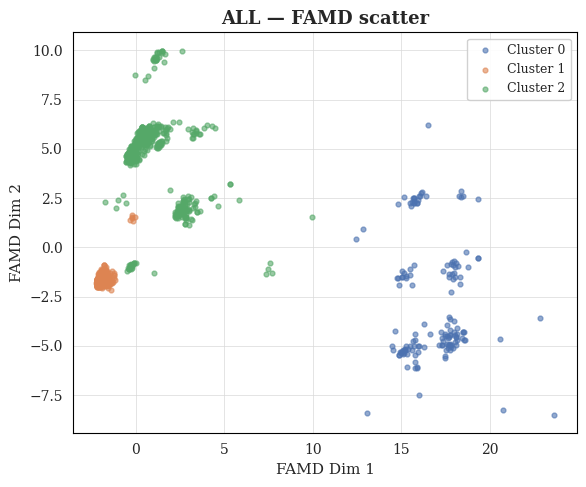

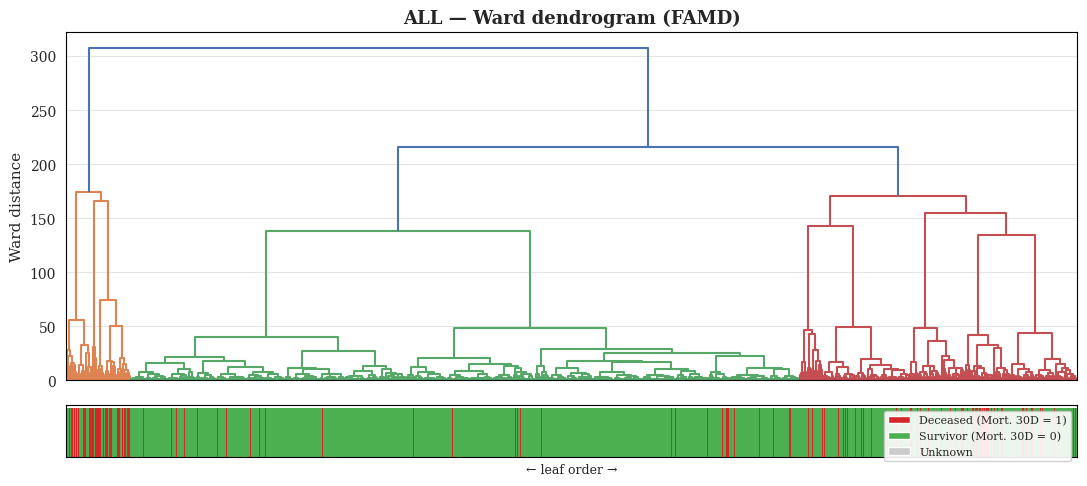

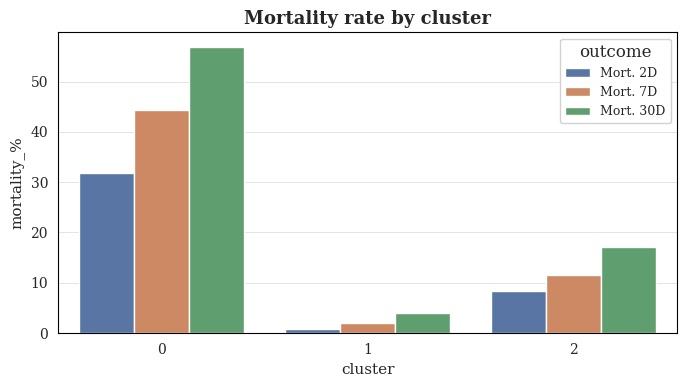

In [ ]:
def famd_ward_pipeline(
    df: pd.DataFrame,
    features: Sequence[str],
    k: int = 3,
    n_components: int = 12,
    random_state: int = RANDOM_STATE,
    low_card_as_cat: bool = True,
    low_card_threshold: int = 3,
) -> Dict[str, object]:
    """FAMD dimensionality reduction + Ward hierarchical clustering.

    Parameters
    ----------
    df : pd.DataFrame
        Input data.
    features : Sequence[str]
        Column names to include (missing columns silently skipped).
    k : int
        Number of clusters.
    n_components : int
        Number of FAMD latent dimensions.
    low_card_as_cat : bool
        If True, numeric columns with ≤ low_card_threshold unique values
        are treated as categorical (appropriate for binary flags).
    low_card_threshold : int
        Cardinality threshold for the above reclassification.

    Returns
    -------
    Dict with keys: features, X_f, Z, labels, metrics.
    """
    feats = [c for c in features if c in df.columns]
    X = df[feats].copy()

    num_cols = X.select_dtypes(include=["number"]).columns.tolist()
    cat_cols = [c for c in X.columns if c not in num_cols]

    if low_card_as_cat:
        for c in num_cols.copy():
            if X[c].nunique(dropna=True) <= low_card_threshold:
                num_cols.remove(c)
                cat_cols.append(c)

    if num_cols:
        X[num_cols] = SimpleImputer(strategy="median").fit_transform(X[num_cols])
        X[num_cols] = StandardScaler().fit_transform(X[num_cols])
    if cat_cols:
        X[cat_cols] = SimpleImputer(strategy="most_frequent").fit_transform(X[cat_cols])
        for c in cat_cols:
            X[c] = X[c].astype("category")

    famd = prince.FAMD(
        n_components=min(n_components, X.shape[1]),
        n_iter=10,
        random_state=random_state,
    ).fit(X)

    X_f = famd.row_coordinates(X)
    Z = linkage(X_f.values, method="ward")
    labels = fcluster(Z, t=k, criterion="maxclust") - 1

    met = {
        "silhouette":        float(silhouette_score(X_f.values, labels)),
        "calinski_harabasz": float(calinski_harabasz_score(X_f.values, labels)),
        "davies_bouldin":    float(davies_bouldin_score(X_f.values, labels)),
    }
    return {"features": feats, "X_f": X_f, "Z": Z, "labels": labels, "metrics": met}


def plot_famd_scatter(X_f: pd.DataFrame, labels: np.ndarray, title: str,
                      save_path: Optional[str] = None) -> None:
    """2D scatter of FAMD dimensions 1-2, coloured by cluster."""
    plt.figure(figsize=(6, 5))
    for lab in np.unique(labels):
        mask = labels == lab
        plt.scatter(X_f.iloc[mask, 0], X_f.iloc[mask, 1],
                    s=12, alpha=0.6, label=f"Cluster {lab}")
    plt.xlabel("FAMD Dim 1")
    plt.ylabel("FAMD Dim 2")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path)
    plt.show()


def plot_dendrogram(Z: np.ndarray, title: str,
                    df_ref: pd.DataFrame = None,
                    mort_col: str = "Mort. 30D",
                    save_path: Optional[str] = None) -> None:
    """Plot a Ward dendrogram with an optional mortality leaf overlay.

    Parameters
    ----------
    Z : np.ndarray
        Linkage matrix from scipy.cluster.hierarchy.linkage.
    title : str
        Plot title.
    df_ref : pd.DataFrame or None
        Reference DataFrame; if provided, a leaf strip coloured by mortality
        (red = deceased, green = survivor) is plotted below the dendrogram.
    mort_col : str
        Column name for the mortality indicator (default: "Mort. 30D").
    """
    fig, axes = plt.subplots(
        2 if df_ref is not None else 1, 1,
        figsize=(11, 5 if df_ref is not None else 4),
        gridspec_kw={"height_ratios": [4, 0.6]} if df_ref is not None else None,
    )
    ax_dend = axes[0] if df_ref is not None else axes

    dd = dendrogram(Z, no_labels=True, ax=ax_dend,
                    color_threshold=0.7 * max(Z[:, 2]))
    ax_dend.set_title(title, fontweight="bold")
    ax_dend.set_ylabel("Ward distance")
    ax_dend.set_xlabel("")

    if df_ref is not None and mort_col in df_ref.columns:
        leaves = dd["leaves"]
        mort_vals = pd.to_numeric(df_ref.iloc[leaves][mort_col], errors="coerce")
        colors = [
            TFG_COLORS["dead_leaf"] if v == 1
            else (TFG_COLORS["alive_leaf"] if v == 0 else "#cccccc")
            for v in mort_vals
        ]
        ax_strip = axes[1]
        ax_strip.bar(np.arange(len(leaves)), 1, color=colors,
                     width=1.0, linewidth=0)
        ax_strip.set_xlim(-0.5, len(leaves) - 0.5)
        ax_strip.set_yticks([])
        ax_strip.set_xticks([])
        ax_strip.set_xlabel("← leaf order →", fontsize=9)

        # Legend
        from matplotlib.patches import Patch
        legend_elements = [
            Patch(facecolor=TFG_COLORS["dead_leaf"],  label="Deceased (Mort. 30D = 1)"),
            Patch(facecolor=TFG_COLORS["alive_leaf"], label="Survivor (Mort. 30D = 0)"),
            Patch(facecolor="#cccccc",                label="Unknown"),
        ]
        ax_strip.legend(handles=legend_elements, loc="upper right",
                        fontsize=8, frameon=True)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path)
    plt.show()


def plot_mortality_bars(df: pd.DataFrame, cluster_col: str,
                        mort_cols: Sequence[str],
                        save_path: Optional[str] = None) -> None:
    """Bar chart of mortality rate per cluster per mortality endpoint."""
    rows = []
    for m in mort_cols:
        if m not in df.columns:
            continue
        tmp = pd.DataFrame({cluster_col: df[cluster_col], m: df[m]}).dropna()
        rate = tmp.groupby(cluster_col)[m].mean() * 100
        for k, v in rate.items():
            rows.append({"outcome": m, "cluster": k, "mortality_%": float(v)})
    out = pd.DataFrame(rows)
    if out.empty:
        return
    plt.figure(figsize=(7, 4))
    sns.barplot(data=out, x="cluster", y="mortality_%", hue="outcome")
    plt.title("Mortality rate by cluster")
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path)
    plt.show()


# --- Feature sets (Triaje excluded — classified as hospital variable) ---
PRE_MIXED = [c for c in ["Edad", "Sexo", "FR", "SpO2", "TAS", "TAD", "TAM",
                          "FC", "TT", "GCS", "Lactato", "Glucemia"]
             if c in df.columns]

ALL_MIXED = PRE_MIXED + [c for c in ["O2 sup.", "Gafas", "Venturi", "Resrv.",
                                      "Nebul.", "VNI", "IOT", "VAD", "VM",
                                      "MAVA", "TTE"]
                         if c in df.columns]

# --- PRE set ---
pre_res = famd_ward_pipeline(df, PRE_MIXED, k=3, n_components=10)
df["cluster_famd_pre_k3"] = pre_res["labels"]

# --- ALL set ---
all_res = famd_ward_pipeline(df, ALL_MIXED, k=3, n_components=12)
df["cluster_famd_all_k3"] = all_res["labels"]

famd_metrics_df = pd.DataFrame([{"set": "PRE", **pre_res["metrics"]}, {"set": "ALL", **all_res["metrics"]}])
display(Markdown("### FAMD + Ward metrics"))
display(famd_metrics_df)
famd_metrics_df.to_csv(os.path.join(NB2_OUTPUT_DIR, "tbl_12_famd_metrics.csv"), index=False)

plot_famd_scatter(pre_res["X_f"], df["cluster_famd_pre_k3"].values, "PRE — FAMD scatter",
                  save_path=os.path.join(NB2_OUTPUT_DIR, "fig_12a_famd_pre_scatter.png"))
plot_dendrogram(pre_res["Z"], "PRE — Ward dendrogram (FAMD)", df_ref=df,
                save_path=os.path.join(NB2_OUTPUT_DIR, "fig_12b_famd_pre_dendrogram.png"))

plot_famd_scatter(all_res["X_f"], df["cluster_famd_all_k3"].values, "ALL — FAMD scatter",
                  save_path=os.path.join(NB2_OUTPUT_DIR, "fig_12c_famd_all_scatter.png"))
plot_dendrogram(all_res["Z"], "ALL — Ward dendrogram (FAMD)", df_ref=df,
                save_path=os.path.join(NB2_OUTPUT_DIR, "fig_12d_famd_all_dendrogram.png"))

plot_mortality_bars(df, "cluster_famd_all_k3", MORT_COLS,
                   save_path=os.path.join(NB2_OUTPUT_DIR, "fig_12e_famd_mortality_bars.png"))


## **13. Gower distance dendrograms (mixed-type structure)**

Gower distance natively handles mixed data types without requiring a prior factorisation step:
- **Numeric variables**: Manhattan distance, normalised by the range (MinMax scaling).
- **Categorical variables**: simple matching (0 if same, 1 if different).

The overall distance is the average across all variables.

### Constraint

Computing a full pairwise Gower matrix is O(n²) in time and memory. Therefore it is **subsampled** to `max_points = 400` patients (randomly selected, seeded) before computing the matrix.

### Function: `gower_distance_matrix(X)`

| Parameter | Type | Description |
|-----------|------|-------------|
| `X` | `pd.DataFrame` | Mixed-type data (numeric + categorical) |
| **Returns** | `np.ndarray` | Square distance matrix of shape (n, n) |

### Function: `plot_gower_dendrogram_with_overlay()`

| Parameter | Type | Default | Description |
|-----------|------|---------|-------------|
| `df` | `pd.DataFrame` | — | Full dataset |
| `features` | `Sequence[str]` | — | Columns for distance computation |
| `overlay` | `pd.Series` | `None` | Optional variable to colour the leaf order (e.g., cluster labels or mortality) |
| `linkage_method` | `str` | `"average"` | Agglomerative linkage criterion |
| `max_points` | `int` | `400` | Subsample size |

### Output

| Output | Type | Description |
|--------|------|-------------|
| Dendrogram | plot | Gower-based hierarchical structure |
| Leaf overlay | plot | Colour strip showing cluster or mortality alignment with dendrogram leaf order |


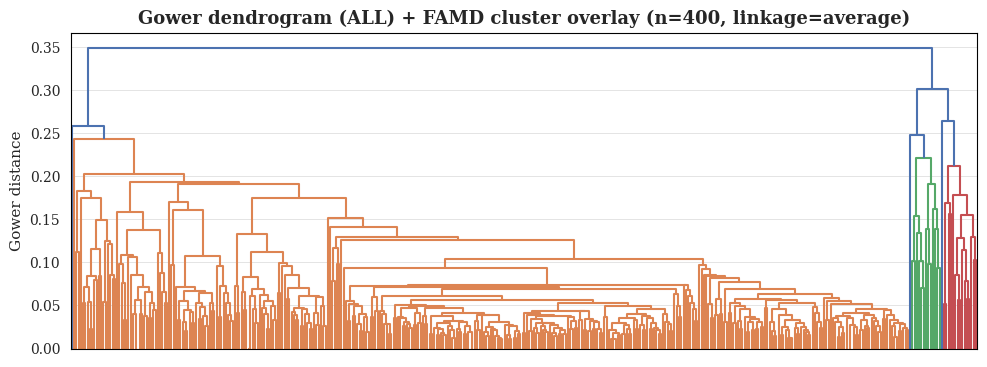

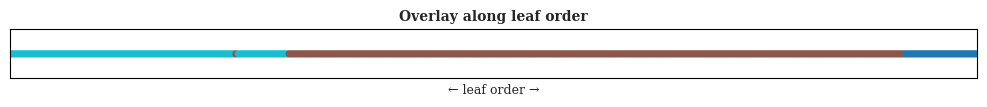

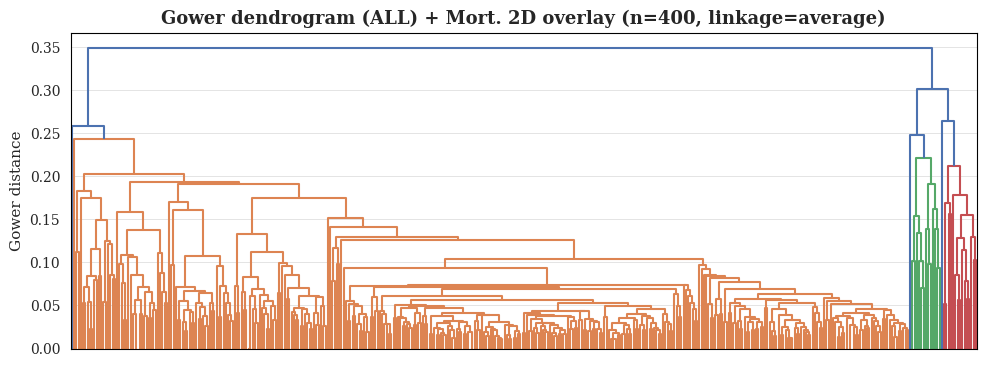

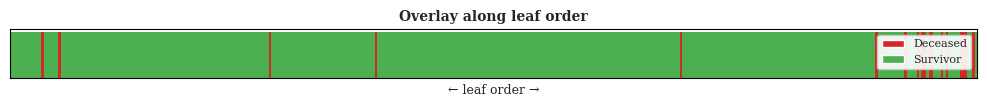

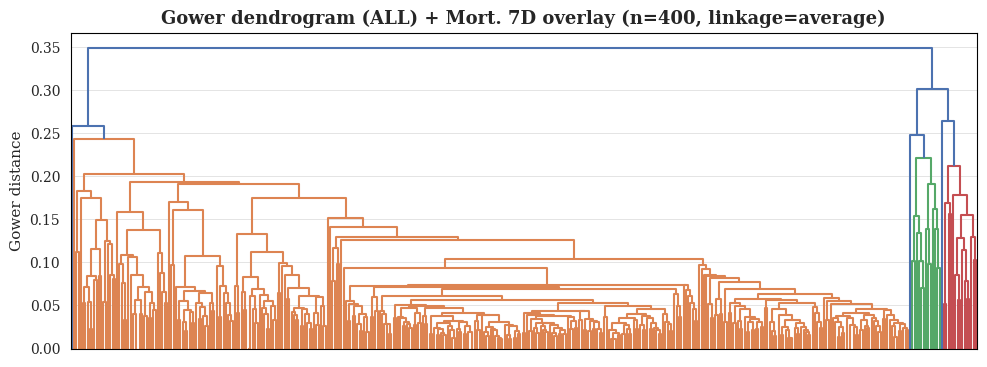

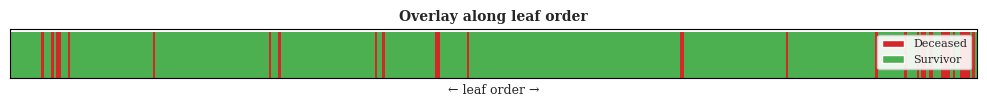

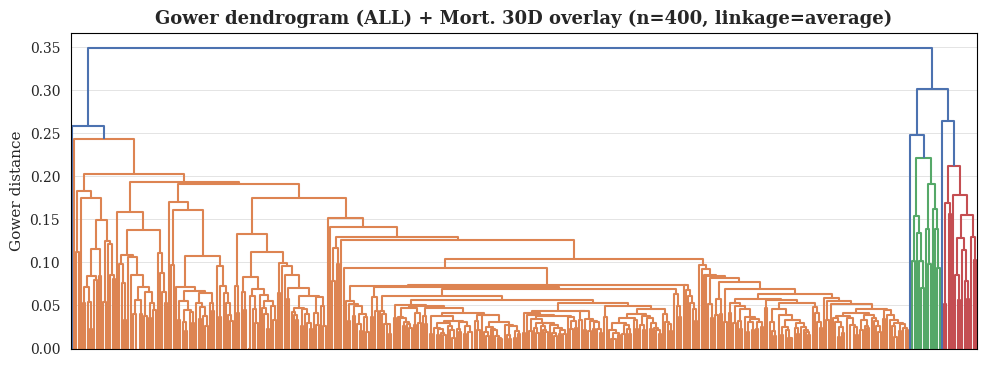

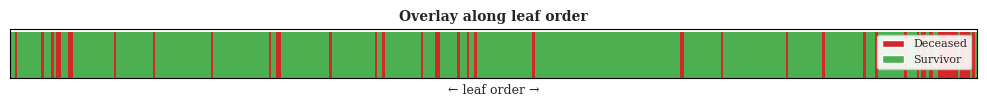

In [ ]:
def gower_distance_matrix(X: pd.DataFrame) -> np.ndarray:
    """Compute a pairwise Gower distance matrix for mixed-type data.

    Numeric columns: normalised Manhattan distance (MinMax scaled).
    Categorical columns: simple matching distance (0 = same, 1 = different).

    Parameters
    ----------
    X : pd.DataFrame
        Mixed-type input (numeric and categorical).

    Returns
    -------
    np.ndarray
        Square distance matrix of shape (n, n), values in [0, 1].
    """
    X = X.copy()
    n = X.shape[0]

    num_cols = X.select_dtypes(include=["number"]).columns.tolist()
    cat_cols = [c for c in X.columns if c not in num_cols]

    if num_cols:
        X[num_cols] = MinMaxScaler().fit_transform(X[num_cols])
    for c in cat_cols:
        X[c] = X[c].astype("object")

    D = np.zeros((n, n), dtype=float)
    p = 0

    for c in num_cols:
        v = X[c].to_numpy()
        D += np.abs(v[:, None] - v[None, :])
        p += 1
    for c in cat_cols:
        v = X[c].to_numpy()
        D += (v[:, None] != v[None, :]).astype(float)
        p += 1

    if p:
        D /= p
    np.fill_diagonal(D, 0.0)
    return D


def plot_gower_dendrogram_with_overlay(
    df: pd.DataFrame,
    features: Sequence[str],
    overlay: Optional[pd.Series] = None,
    title: str = "",
    linkage_method: str = "average",
    max_points: int = 400,
    seed: int = RANDOM_STATE,
    save_path: Optional[str] = None,
    save_path_overlay: Optional[str] = None,
) -> None:
    """Plot a Gower-distance dendrogram with an optional leaf overlay.

    Parameters
    ----------
    df : pd.DataFrame
        Full dataset.
    features : Sequence[str]
        Columns for distance computation.
    overlay : pd.Series or None
        Variable to colour along the leaf order (e.g., cluster labels).
    title : str
        Plot title.
    linkage_method : str
        Agglomerative linkage: 'average', 'ward', 'complete', 'single'.
    max_points : int
        Subsample size (Gower is O(n²)).
    seed : int
        Random seed for subsampling.
    """
    feats = [c for c in features if c in df.columns]
    X = df[feats].copy()

    num_cols = X.select_dtypes(include=["number"]).columns.tolist()
    cat_cols = [c for c in X.columns if c not in num_cols]
    if num_cols:
        X[num_cols] = X[num_cols].fillna(X[num_cols].median())
    for c in cat_cols:
        mode = X[c].mode(dropna=True)
        X[c] = X[c].fillna(mode.iloc[0] if len(mode) else "NA").astype("object")

    if len(X) > max_points:
        idx = np.random.default_rng(seed).choice(len(X), size=max_points, replace=False)
        Xs = X.iloc[idx]
        ovs = overlay.iloc[idx] if overlay is not None else None
    else:
        Xs = X
        ovs = overlay

    D = gower_distance_matrix(Xs)
    Z = linkage(squareform(D, checks=False), method=linkage_method)

    plt.figure(figsize=(10, 3.8))
    dd = dendrogram(Z, no_labels=True)
    plt.title(title + f" (n={len(Xs)}, linkage={linkage_method})")
    plt.ylabel("Gower distance")
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path)
    plt.show()

    if ovs is not None:
        leaves = dd["leaves"]
        vals = pd.Series(ovs.to_numpy())[leaves].to_numpy()

        # Detect binary mortality overlay (0/1) vs continuous cluster labels
        unique_vals = np.unique(vals[~np.isnan(vals.astype(float))])
        is_binary = set(unique_vals.tolist()).issubset({0.0, 1.0, 0, 1})

        fig2, ax2 = plt.subplots(figsize=(10, 1.2))
        if is_binary:
            colors = [
                TFG_COLORS["dead_leaf"]  if v == 1
                else (TFG_COLORS["alive_leaf"] if v == 0 else "#cccccc")
                for v in vals
            ]
            ax2.bar(np.arange(len(leaves)), 1, color=colors,
                    width=1.0, linewidth=0)
            from matplotlib.patches import Patch
            legend_elements = [
                Patch(facecolor=TFG_COLORS["dead_leaf"],  label="Deceased"),
                Patch(facecolor=TFG_COLORS["alive_leaf"], label="Survivor"),
            ]
            ax2.legend(handles=legend_elements, loc="upper right",
                       fontsize=8, frameon=True)
        else:
            # Continuous or cluster: use colormap
            ax2.scatter(np.arange(len(vals)), np.zeros_like(vals),
                        c=vals, cmap="tab10", s=18)
        ax2.set_xlim(-0.5, len(leaves) - 0.5)
        ax2.set_yticks([])
        ax2.set_xticks([])
        ax2.set_xlabel("← leaf order →", fontsize=9)
        ax2.set_title("Overlay along leaf order", fontsize=10)
        plt.tight_layout()
        if save_path_overlay:
            plt.savefig(save_path_overlay)
        plt.show()


# --- Gower dendrogram with FAMD cluster overlay ---
plot_gower_dendrogram_with_overlay(
    df, ALL_MIXED,
    overlay=df["cluster_famd_all_k3"],
    title="Gower dendrogram (ALL) + FAMD cluster overlay",
    save_path=os.path.join(NB2_OUTPUT_DIR, "fig_13a_gower_famd_dendrogram.png"),
    save_path_overlay=os.path.join(NB2_OUTPUT_DIR, "fig_13a_gower_famd_leaf.png"),
)

# --- Gower dendrogram with mortality overlay ---
for mort in MORT_COLS:
    if mort in df.columns:
        _mc = mort.replace(" ", "_").replace(".", "")
        plot_gower_dendrogram_with_overlay(
            df, ALL_MIXED,
            overlay=df[mort],
            title=f"Gower dendrogram (ALL) + {mort} overlay",
            save_path=os.path.join(NB2_OUTPUT_DIR, f"fig_13b_gower_{_mc}.png"),
            save_path_overlay=os.path.join(NB2_OUTPUT_DIR, f"fig_13b_gower_{_mc}_leaf.png"),
        )


## **14. Feature screening — mutual information**

Mutual information (MI) quantifies the statistical dependency between each feature and the target variable. Unlike correlation, MI captures **non-linear** relationships and works with both continuous and categorical inputs.

### Target selection: Mort. 30D

The target for feature screening is set to **Mort. 30D** (30-day mortality). Under the cumulative coding scheme, this mortality has the largest percentage across the three outcomes.

**Preprocessing for MI estimation**:
1. Continuous variables: median imputation + z-score standardisation.
2. Categorical and ordinal variables: mode imputation + one-hot encoding.
3. These transformations are local to this section and do not affect the main `df`.
4. All mortality endpoints and derived columns are excluded from features to prevent leakage.

> **Aggregation**: Since OHE produces multiple dummy columns per categorical variable, MI scores are aggregated back to the original variable level by taking the **maximum MI** across all OHE levels of each variable.

### Output

| Output | Type | Description |
|--------|------|-------------|
| MI ranking (encoded) | `pd.Series` | Top 40 features by MI (includes individual OHE dummies) |
| MI ranking (aggregated) | `pd.Series` | Top 25 original variables by max MI across OHE levels |


In [ ]:
# ============================================================
# Mutual Information vs TARGET
# ============================================================

TARGET = TARGET_COL if TARGET_COL in df.columns else (MORT_COLS[-1] if MORT_COLS else None)

if TARGET is None:
    display(Markdown("⚠️ No mortality column found — MI screening skipped."))
else:
    y = df[TARGET].astype("Int64")
    mask = y.isin([0, 1])
    y = y[mask].astype(int)

    # Drop all mortality endpoints from features (critical)
    DROP_COLS = [c for c in ALL_MORT_COLS if c in df.columns]
    DROP_COLS += [c for c in ["Fecha", "Mort_scenario", "cluster_kmeans_k3",
                          "cluster_famd_pre_k3", "cluster_famd_all_k3"] if c in df.columns]

    X_base = df.loc[mask].drop(columns=DROP_COLS, errors="ignore").copy()

    cont_cols2, cat_cols2 = split_features(X_base, exclude=(), cat_unique_threshold=12)
    X = X_base[cont_cols2 + cat_cols2].copy()

    pre = ColumnTransformer([
        ("num", Pipeline([
            ("imp", SimpleImputer(strategy="median")),
            ("sc", StandardScaler()),
        ]), cont_cols2),
        ("cat", Pipeline([
            ("imp", SimpleImputer(strategy="most_frequent")),
            ("oh", OneHotEncoder(handle_unknown="ignore")),
        ]), cat_cols2),
    ])

    X_enc = pre.fit_transform(X)

    # Feature names
    feat_names = list(cont_cols2)
    if cat_cols2:
        ohe = pre.named_transformers_["cat"].named_steps["oh"]
        feat_names += list(ohe.get_feature_names_out(cat_cols2))

    # Discrete mask: OHE features are discrete, numeric are continuous
    n_num = len(cont_cols2)
    discrete_mask = np.array([False]*n_num + [True]*(len(feat_names) - n_num))

    mi = mutual_info_classif(
        X_enc, y,
        discrete_features=discrete_mask,
        random_state=RANDOM_STATE
    )

    mi_s = pd.Series(mi, index=feat_names).sort_values(ascending=False)
    display(Markdown(f"### Mutual Information vs `{TARGET}` (top 40 encoded features)"))
    display(mi_s.head(40))
    mi_s.to_csv(os.path.join(NB2_OUTPUT_DIR, "tbl_14_mutual_information.csv"), header=["MI_score"])

### Mutual Information vs `Mort. 30D` (top 40 encoded features)

,0
SpO2,0.057707
FiO2_1.0,0.050070
GCS,0.048570
FiO2_0.21,0.046049
O2 sup._1.0,0.046013
O2 sup._0.0,0.046013
MAVA_0.0,0.043862
MAVA_1.0,0.043862
VM_0.0,0.042836
VM_1.0,0.042836


## **15. Conclusions (auto-generated summary)**

This cell compiles key findings from the analyses above into a compact, machine-generated summary. The summary is derived programmatically from computed variables (event rates, missingness, cluster mortality gradients) to avoid manual transcription errors.

### Output

A bullet-point summary including:
- Cohort size and variable count.
- Mortality event rates at each endpoint.
- Variables with highest residual missingness.
- Variables with out-of-range flags.
- Cluster-level mortality gradients (for the ALL-set FAMD clustering).

In [ ]:
# ============================================================
# Auto-generated summary
# ============================================================

concl = []

concl.append(f"- Cohort size: **N = {len(df)}**, variables: **p = {df.shape[1]}** "
             f"(including cluster and scenario columns added in this notebook).")

# Cumulative event rates
for mort in MORT_COLS:
    if mort in df.columns:
        y = df[mort].astype("Int64")
        valid = y.isin([0, 1])
        rate = float(y[valid].mean() * 100) if valid.any() else np.nan
        concl.append(f"- `{mort}` cumulative event rate: **{rate:.2f}%** "
                     f"(valid rows={int(valid.sum()):,}).")

# Missingness
miss_mod = df.isna().mean().mul(100).sort_values(ascending=False)
top_m = miss_mod[miss_mod > 0].head(5)
if len(top_m):
    concl.append("- Highest residual missingness: "
                 + "; ".join([f"{i} ({v:.2f}%)" for i, v in top_m.items()]))

# Plausibility
oor_rows = []
for col, (lo, hi) in PLAUSIBLE_RANGES.items():
    if col not in df.columns:
        continue
    s = pd.to_numeric(df[col], errors="coerce")
    out = ((s < lo) | (s > hi)).sum()
    oor_rows.append((col, int(out)))
oor_rows = sorted(oor_rows, key=lambda x: x[1], reverse=True)[:5]
if oor_rows and oor_rows[0][1] > 0:
    concl.append("- Most out-of-range flags: "
                 + "; ".join([f"{c} ({n})" for c, n in oor_rows]))

# Cluster mortality gradient
if "cluster_famd_all_k3" in df.columns:
    for mort in MORT_COLS:
        if mort not in df.columns:
            continue
        tmp = pd.DataFrame({"cluster": df["cluster_famd_all_k3"], "y": df[mort]}).dropna()
        rates = (tmp.groupby("cluster")["y"].mean() * 100).round(2)
        concl.append(f"- Mortality by ALL-clusters for `{mort}`: "
                     + ", ".join([f"C{k} = {v}%" for k, v in rates.items()]))

display(Markdown("### Key takeaways\n" + "\n".join(concl)))


### Key takeaways
- Cohort size: **N = 2376**, variables: **p = 37** (including cluster and scenario columns added in this notebook).
- `Mort. 2D` cumulative event rate: **4.80%** (valid rows=2,376).
- `Mort. 7D` cumulative event rate: **7.28%** (valid rows=2,376).
- `Mort. 30D` cumulative event rate: **10.98%** (valid rows=2,376).
- Most out-of-range flags: TAS (5); TAM (3); FC (2); SpO2 (1); TAD (1)
- Mortality by ALL-clusters for `Mort. 2D`: C0 = 31.79%, C1 = 0.76%, C2 = 8.28%
- Mortality by ALL-clusters for `Mort. 7D`: C0 = 44.37%, C1 = 1.97%, C2 = 11.5%
- Mortality by ALL-clusters for `Mort. 30D`: C0 = 56.95%, C1 = 4.01%, C2 = 17.18%